# Trabajo 4 - Grupo 6  

**Curso:** INTRODUCCIÓN A CIENCIA DE DATOS Y MACHINE LEARNING CON PYTHON (ICD)              
**Profesor:** Luis Zapata Bobadilla  

---

## Integrantes
- Carmen Crisanto, César Jair  
- Miranda Sanchez, Alex Abraham Patrick  
- Prado Chafloque, Sarai Elizabeth  
- Reategui Zapata, Joaquin Alejandro  

---

## Pregunta de investigación
**¿Cómo influye el déficit fiscal en las expectativas empresariales de corto plazo (3 meses) y largo plazo (12 meses)?**  


## Objetivo
Este trabajo busca aplicar de forma integrada los conceptos estudiados en el curso de Machine Learning con Python. A partir de un conjunto de datos macroeconómicos del BCRP, realizamos una exploración inicial de datos (EDA), la construcción de un modelo baseline, la comparación de modelos más complejos, el diseño de un DAG para analizar posibles relaciones causales, el entrenamiento de una red neuronal.

El objetivo central es evaluar qué modelo predice mejor las expectativas empresariales y analizar qué factores económicos podrían estar detrás de dicha relación.

#Trabajo 1. EXPLORACIÓN DE DATOS (EDA)

In [ ]:
import requests, json, pandas as pd, numpy as np, re

series = [
    "PN39524FM",  # Déficit fiscal
    "PD38045AM",  # Expectativas economía 3m
    "PD37981AM",  # Expectativas economía 12m
    "PD04722MM",  # Tasa de referencia
]
inicio = "2015-01"
fin    = "2025-12"

MESES = {'Ene':'01','Feb':'02','Mar':'03','Abr':'04','May':'05','Jun':'06',
         'Jul':'07','Ago':'08','Sep':'09','Oct':'10','Nov':'11','Dic':'12'}

def parse_fecha(s):
    s = str(s).strip()
    m = re.match(r'^([A-Za-zÁÉÍÓÚÑáéíóúñ]{3})\.(\d{4})$', s)
    if m:
        mm = MESES.get(m.group(1).title())
        return pd.to_datetime(f"{m.group(2)}-{mm}-01", errors="coerce")
    return pd.to_datetime(s, errors="coerce", dayfirst=False)

def to_float(x):
    if x in (None, 'n.d.', 'NaN', ''):
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

all_data = {}

for codigo in series:
    url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigo}/json/{inicio}/{fin}"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    try:
        data = r.json()
    except json.JSONDecodeError:
        data = json.loads(r.text.lstrip("\ufeff").strip())

    rows = []
    if isinstance(data, dict) and 'periods' in data:
        for per in data['periods']:
            fecha = parse_fecha(per.get('name'))
            vals = per.get('values', [])
            val = to_float(vals[0]) if vals else np.nan
            rows.append({'date': fecha, codigo: val})
        df_tmp = pd.DataFrame(rows).set_index('date').sort_index()
    elif isinstance(data, dict) and 'series' in data:
        rows = {}
        for s in data['series']:
            if s.get('code') == codigo:
                for p in s.get('periods', []):
                    fecha = parse_fecha(p.get('name'))
                    val = to_float(p.get('values', [None])[0])
                    rows[fecha] = val
        df_tmp = pd.Series(rows, name=codigo).to_frame()
    else:
        raise ValueError(f"Respuesta del API no reconocida para {codigo}")

    all_data[codigo] = df_tmp

# Combinar todos los DataFrames en uno solo por índice (fecha)
df4 = pd.concat(all_data.values(), axis=1)

# Reindex para incluir todos los meses del rango
idx = pd.date_range(start=f"{inicio}-01", end=f"{fin}-01", freq="MS")
df4 = df4.reindex(idx)
df4.index.name = "date"

alias = {
    "PN39524FM":"deficit_fiscal",
    "PD38045AM":"exp_eco_3m",
    "PD37981AM":"exp_eco_12m",
    "PD04722MM":"tasa_ref",
}

df4 = df4.rename(columns=alias)

# --- Aquí rellenas los NaN con el último valor válido hacia adelante ---
df4 = df4.fillna(method='ffill')

print("Dimensiones:", df4.shape)
print("Columnas:", df4.columns.tolist())
print("Nulos por serie después de fillna:\n", df4.isna().sum())
display(df4.head(10))
display(df4.tail(10))


Dimensiones: (132, 4)
Columnas: ['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref']
Nulos por serie después de fillna:
 deficit_fiscal    0
exp_eco_3m        0
exp_eco_12m       0
tasa_ref          0
dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17572\1790928800.py:82: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df4 = df4.fillna(method='ffill')


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref
date,,,,
2015-01-01,-0.2696,54.2320,65.1899,3.2500
2015-02-01,-0.3337,50.1577,60.5346,3.2500
2015-03-01,-0.3994,49.3884,56.0606,3.2500
2015-04-01,-0.6820,46.7422,55.5398,3.2500
2015-05-01,-0.8714,45.0704,53.8352,3.2500
2015-06-01,-0.9351,50.6250,55.4140,3.2500
2015-07-01,-0.9044,46.7192,54.0576,3.2500
2015-08-01,-0.9963,42.2222,49.2629,3.2500
2015-09-01,-1.3327,43.2225,50.6394,3.5000


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref
date,,,,
2025-03-01,-3.3055,53.9344,58.0756,4.7500
2025-04-01,-2.8680,52.1311,57.9038,4.7500
2025-05-01,-2.6642,53.9655,56.8905,4.5000
2025-06-01,-2.5923,52.9032,56.6445,4.5000
2025-07-01,-2.5894,54.5455,58.3056,4.5000
2025-08-01,-2.3996,54.4326,60.1476,4.5000
2025-09-01,-2.4779,55.6314,61.0915,4.2500
2025-10-01,-2.2975,55.8923,60.9541,4.2500
2025-11-01,-2.2975,55.8923,60.9541,4.2500


In [ ]:
# Diccionario para renombrar columnas
rename_dict = {
    "Expectativas_12m": "Expectativas (12m)",
    "Expectativas_3m": "Expectativas (3m)",
    "Tasa_Referencia": "Tasa de referencia (%)",
    "Deficit_Fiscal": "Déficit fiscal (% PBI, 12m)"
}

# Suponiendo que tu DataFrame se llama df
df4 = df4.rename(columns=rename_dict)


In [ ]:
df4.head()


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref
date,,,,
2015-01-01,-0.2696,54.2320,65.1899,3.2500
2015-02-01,-0.3337,50.1577,60.5346,3.2500
2015-03-01,-0.3994,49.3884,56.0606,3.2500
2015-04-01,-0.6820,46.7422,55.5398,3.2500
2015-05-01,-0.8714,45.0704,53.8352,3.2500


La tabla muestra los primeros 12 meses (2015) de las series consolidadas:

Expectativas (12m) y Expectativas (3m): Ambas series inician en valores relativamente altos (65 y 54 en enero 2015) y muestran una caída sostenida en los meses siguientes, lo que refleja un deterioro en la confianza de los agentes económicos.
Tasa de referencia (%): Comienza en 3.25% durante la primera mitad del año y sube gradualmente hacia 3.75% en diciembre, evidenciando que el Banco Central empezó a ajustar la política monetaria en respuesta al contexto.
Déficit fiscal (% del PBI, 12m): Es negativo en todo el periodo, y además se profundiza mes a mes (de –0.27% en enero a –1.91% en diciembre), lo que indica un mayor desequilibrio fiscal.
En conjunto, lo que estamos viendo para 2015 es un deterioro simultáneo en expectativas, un ajuste de política monetaria y un déficit fiscal creciente, un patrón que probablemente se relacione con el contexto económico internacional desfavorable de esos años (caída de precios de commodities, menor crecimiento regional).

In [ ]:
df4.tail()

,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref
date,,,,
2025-08-01,-2.3996,54.4326,60.1476,4.5000
2025-09-01,-2.4779,55.6314,61.0915,4.2500
2025-10-01,-2.2975,55.8923,60.9541,4.2500
2025-11-01,-2.2975,55.8923,60.9541,4.2500
2025-12-01,-2.2975,55.8923,60.9541,4.2500


Las últimas filas abarcan desde abril a agosto de 2025:

Expectativas (12m) y (3m): Se mantienen en un rango de 52–58 puntos, lo que sugiere un nivel moderado de confianza. No se observa un deterioro fuerte, pero tampoco una recuperación clara.
Tasa de referencia (%): Se sitúa en 4.75% en abril y luego desciende a 4.50% desde mayo, indicando un ajuste monetario del BCRP hacia una postura ligeramente más expansiva.
Déficit fiscal (% del PBI, 12m): Continúa en negativo, aunque muestra una leve mejora: pasa de –2.84% en abril a –2.57% en julio, antes de estabilizarse. Esto podría interpretarse como un esfuerzo de consolidación fiscal.
Valores faltantes en agosto 2025: En esa fila aparecen NaN en expectativas y déficit, lo que probablemente se debe a que todavía no se publicaban esos indicadores al momento de extraer los datos.
En conjunto, los últimos registros sugieren un contexto de ligera mejora fiscal y flexibilización monetaria, en un entorno donde las expectativas aún se mantienen estables pero lejos de niveles de fuerte optimismo.

In [ ]:
df4_clean = df4.dropna()

print(df4_clean.tail())
print("Número de filas antes:", len(df4), "| después:", len(df4_clean))
df4_clean.head()

            deficit_fiscal  exp_eco_3m  exp_eco_12m  tasa_ref
date                                                         
2025-08-01         -2.3996     54.4326      60.1476    4.5000
2025-09-01         -2.4779     55.6314      61.0915    4.2500
2025-10-01         -2.2975     55.8923      60.9541    4.2500
2025-11-01         -2.2975     55.8923      60.9541    4.2500
2025-12-01         -2.2975     55.8923      60.9541    4.2500
Número de filas antes: 132 | después: 132


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref
date,,,,
2015-01-01,-0.2696,54.2320,65.1899,3.2500
2015-02-01,-0.3337,50.1577,60.5346,3.2500
2015-03-01,-0.3994,49.3884,56.0606,3.2500
2015-04-01,-0.6820,46.7422,55.5398,3.2500
2015-05-01,-0.8714,45.0704,53.8352,3.2500


In [ ]:
print(df4.columns.tolist())


['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref']


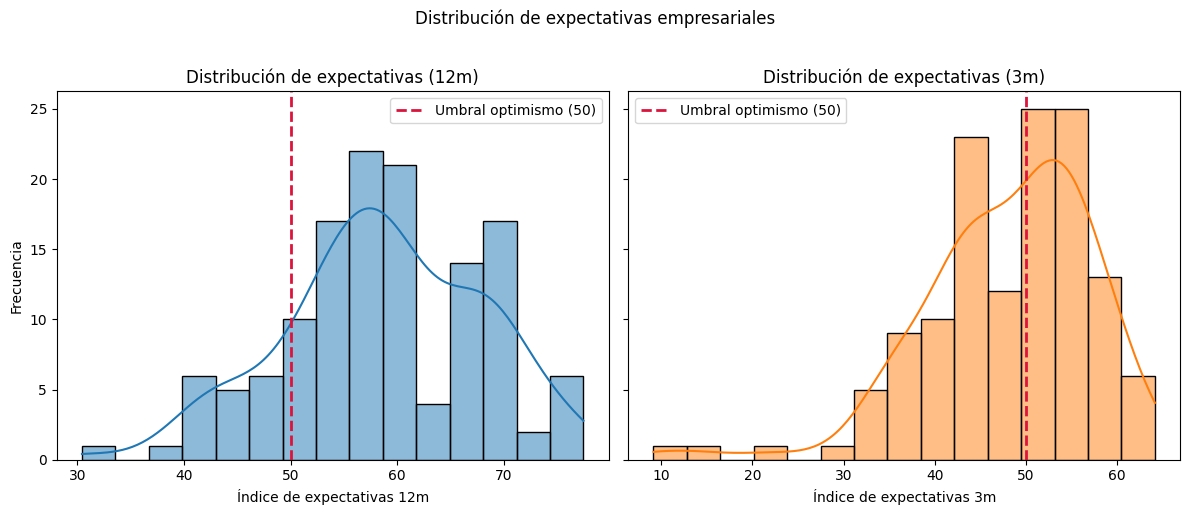

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DataFrame base ---
df_hist = df4[["exp_eco_12m", "exp_eco_3m"]].dropna()

# --- Figura con dos histogramas lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Histograma Expectativas 12m
sns.histplot(df_hist["exp_eco_12m"], bins=15, kde=True, color="tab:blue", ax=axes[0])
axes[0].axvline(50, color="crimson", linestyle="--", linewidth=2, label="Umbral optimismo (50)")
axes[0].set_title("Distribución de expectativas (12m)")
axes[0].set_xlabel("Índice de expectativas 12m")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Histograma Expectativas 3m
sns.histplot(df_hist["exp_eco_3m"], bins=15, kde=True, color="tab:orange", ax=axes[1])
axes[1].axvline(50, color="crimson", linestyle="--", linewidth=2, label="Umbral optimismo (50)")
axes[1].set_title("Distribución de expectativas (3m)")
axes[1].set_xlabel("Índice de expectativas 3m")
axes[1].legend()

plt.suptitle("Distribución de expectativas empresariales", y=1.02)
plt.tight_layout()
plt.show()


Interpretación del gráfico de distribución de expectativas
A 12 meses, la mayor parte de las observaciones se ubica por encima del umbral de 50, reflejando un predominio del optimismo en el horizonte de largo plazo.
A 3 meses, la distribución se concentra más cerca y por debajo del umbral, lo que indica que los empresarios tienden a mostrar mayor pesimismo en el corto plazo.
En síntesis: los agentes económicos confían más en el largo plazo, pero reaccionan con cautela en el corto plazo.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17572\2861418890.py:22: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  s = s.resample("A").last()   # último dato de cada año


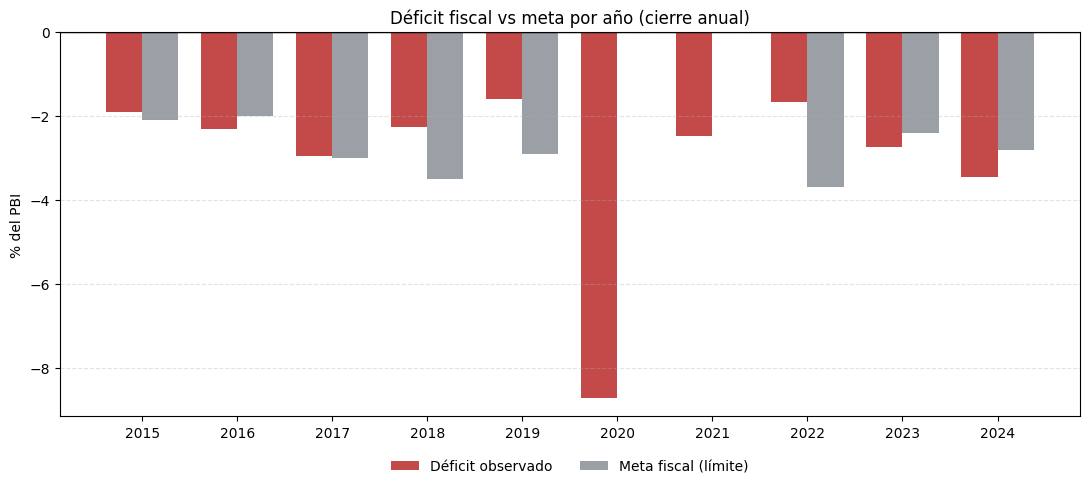

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Nombre real en tu DataFrame ---
col_def = "deficit_fiscal"

# --- Copiar y preparar data ---
dfb = df4.copy()

# Asegurar índice datetime (df4 ya lo tiene mensual)
if not pd.api.types.is_datetime64_any_dtype(dfb.index):
    dfb.index = pd.to_datetime(dfb.index)

dfb = dfb.sort_index()

# Convertir a numérico
dfb[col_def] = pd.to_numeric(dfb[col_def], errors="coerce")

# --- Cierre anual ---
def cierre_anual(s: pd.Series) -> pd.Series:
    s = s.resample("A").last()   # último dato de cada año
    s.index = s.index.year       # usar solo el año
    return s

deficit_cierre = cierre_anual(dfb[col_def])

# Mantener solo hasta 2024
deficit_cierre = deficit_cierre[deficit_cierre.index <= 2024]

# --- Metas fiscales del MEF ---
metas = {
    2015:-2.1, 2016:-2.0, 2017:-3.0, 2018:-3.5, 2019:-2.9,
    2020:None, 2021:None, 2022:-3.7, 2023:-2.4, 2024:-2.8
}

meta_series = pd.Series(metas, dtype="float").reindex(deficit_cierre.index)

# --- DataFrame comparativo ---
df_comp = pd.DataFrame({
    "Déficit observado": deficit_cierre,
    "Meta fiscal": meta_series
})

# --- Gráfico ---
years = df_comp.index.values
x = np.arange(len(years))
w = 0.38

fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x - w/2, df_comp["Déficit observado"], width=w,
       label="Déficit observado", color="#c44949")

ax.bar(x + w/2, df_comp["Meta fiscal"], width=w,
       label="Meta fiscal (límite)", color="#9aa0a6")

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x, years)
ax.set_ylabel("% del PBI")
ax.set_title("Déficit fiscal vs meta por año (cierre anual)")
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Leyenda debajo del gráfico
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


Interpretación del gráfico de déficit fiscal vs meta
El Perú es uno de los países de América Latina con menor déficit fiscal en promedio, lo que refleja un buen control de las cuentas públicas. Esto ha sido posible gracias al sistema de metas fiscales, que establece límites anuales para garantizar la sostenibilidad.

No obstante, el gráfico muestra que estas metas no se han cumplido en los últimos años, con especial énfasis en 2024, cuando el déficit observado superó nuevamente el límite fijado.

Cabe señalar que en 2020 y 2021 hubo excepciones debido a la pandemia, en las cuales se permitió un mayor gasto público para atender la emergencia sanitaria y mitigar los efectos económicos de la crisis.

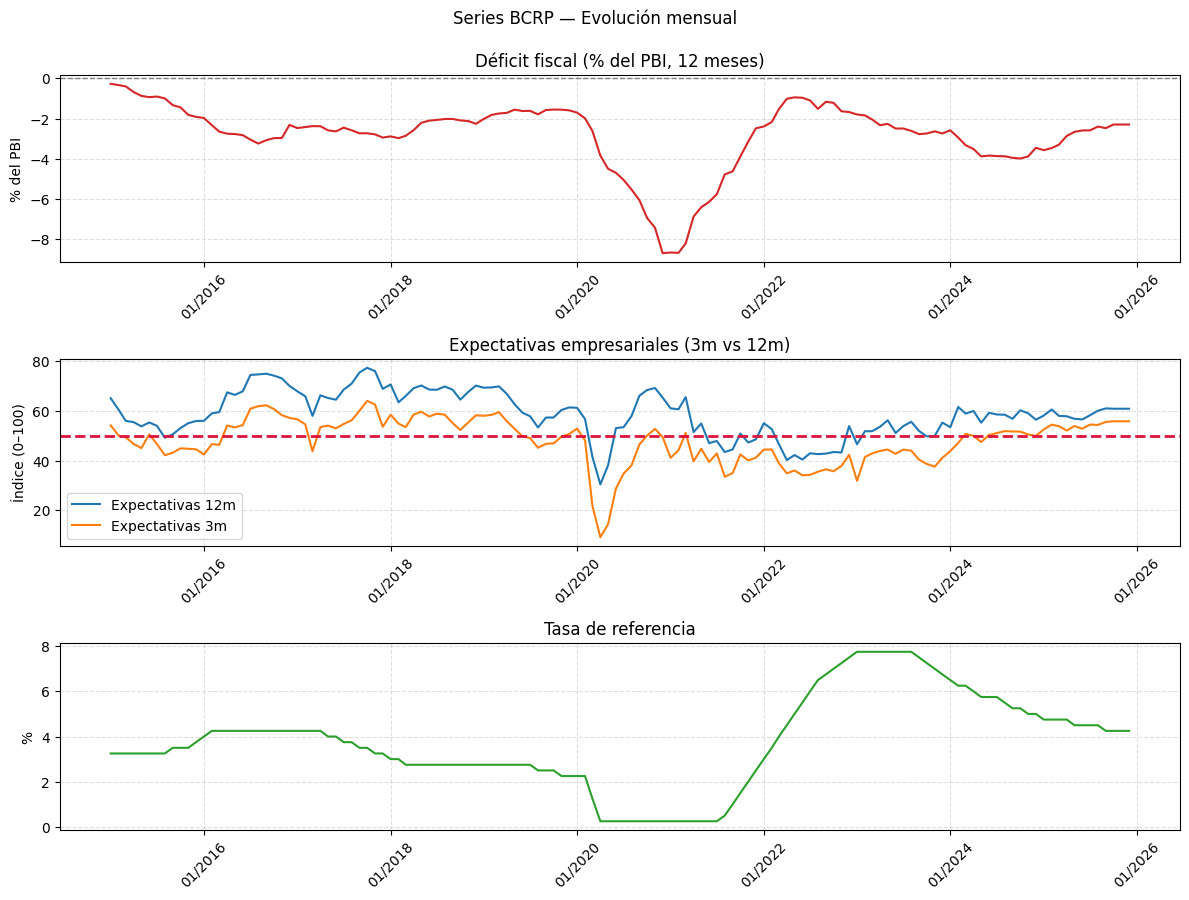

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Preparar DataFrame ---
df_plot = df4.copy()

# Asegurar índice datetime
if not pd.api.types.is_datetime64_any_dtype(df_plot.index):
    df_plot.index = pd.to_datetime(df_plot.index)

df_plot = df_plot.sort_index()

# --- Nombres reales en df4 ---
col_e12 = "exp_eco_12m"
col_e3  = "exp_eco_3m"
col_tir = "tasa_ref"
col_def = "deficit_fiscal"

# --- Figura con 3 paneles ---
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 9))

# Panel 1: Déficit fiscal
axes[0].plot(df_plot.index, df_plot[col_def], color="tab:red")
axes[0].axhline(0, linewidth=1, color="gray", linestyle="--")
axes[0].set_title("Déficit fiscal (% del PBI, 12 meses)")
axes[0].set_ylabel("% del PBI")

# Panel 2: Expectativas 3m vs 12m
axes[1].plot(df_plot.index, df_plot[col_e12], color="tab:blue", label="Expectativas 12m")
axes[1].plot(df_plot.index, df_plot[col_e3],  color="tab:orange", label="Expectativas 3m")
axes[1].axhline(50, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Expectativas empresariales (3m vs 12m)")
axes[1].set_ylabel("Índice (0–100)")
axes[1].legend()

# Panel 3: Tasa de referencia
axes[2].plot(df_plot.index, df_plot[col_tir], color="tab:green")
axes[2].set_title("Tasa de referencia")
axes[2].set_ylabel("%")

# --- Formato de fechas y grilla ---
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.grid(True, linestyle="--", alpha=0.4)

    for label in ax.get_xticklabels():
        label.set_rotation(45)

fig.suptitle("Series BCRP — Evolución mensual", y=0.995)
fig.tight_layout()
plt.show()


Déficit fiscal: la caída abrupta en 2020 refleja la política fiscal expansiva aplicada durante la pandemia, con un déficit cercano al –9% del PBI. A partir de 2021 se observa una corrección, aunque el déficit se mantiene en terreno negativo.

Expectativas empresariales: las de corto plazo (3m) reaccionan con mayor volatilidad, cayendo muy por debajo del umbral de 50 durante la crisis sanitaria, lo que refleja pesimismo generalizado. Las expectativas de 12m, aunque también se deterioran, muestran más resiliencia y se recuperan antes, indicando confianza en el mediano plazo.

Tasa de referencia: el Banco Central respondió reduciendo agresivamente la tasa de referencia en 2020 para estimular la economía. Posteriormente, entre 2021 y 2023, se evidencia un ciclo de alzas con el objetivo de contener la inflación, estabilizándose luego en niveles intermedios.

En conjunto: las tres series capturan la interacción entre política fiscal, política monetaria y percepciones empresariales frente a shocks. En 2020 se observa un “punto de quiebre” claro, donde la caída simultánea del déficit, las expectativas y la tasa de interés evidencian la magnitud de la crisis.

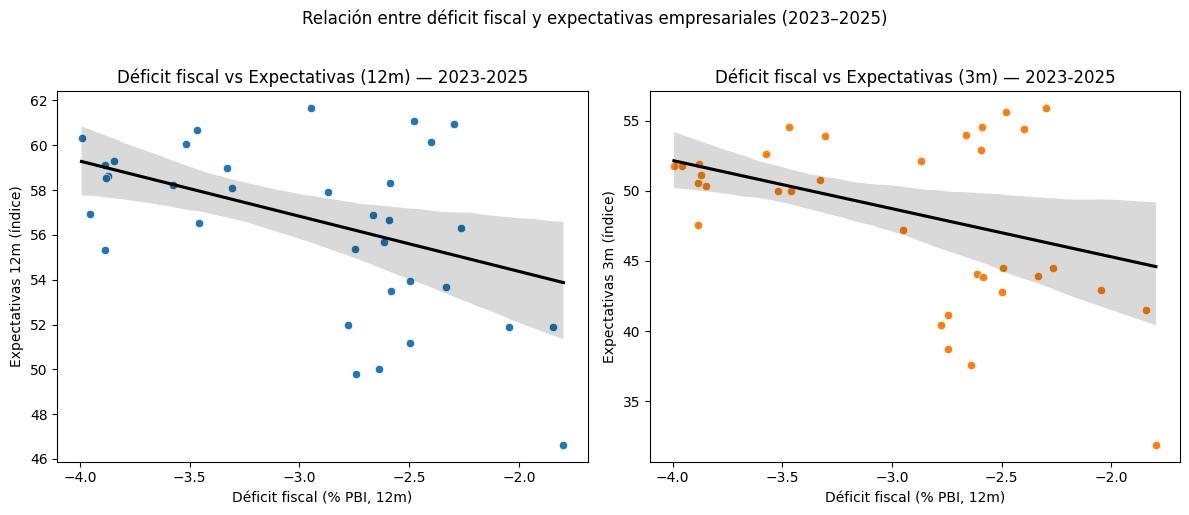

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Preparar DataFrame base ---
df_plot = df4.copy()

# Asegurar índice datetime
if not pd.api.types.is_datetime64_any_dtype(df_plot.index):
    df_plot.index = pd.to_datetime(df_plot.index)

df_plot = df_plot.sort_index()

# Nombres reales en df4
col_def = "deficit_fiscal"
col_e12 = "exp_eco_12m"
col_e3  = "exp_eco_3m"

# --- Filtrar datos 2023-2025 ---
df_recent = df_plot.loc["2023":"2025", [col_def, col_e12, col_e3]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Déficit fiscal vs Expectativas 12m (2023-2025)
sns.scatterplot(
    x=col_def, y=col_e12, data=df_recent,
    ax=axes[0], color="tab:blue"
)
sns.regplot(
    x=col_def, y=col_e12, data=df_recent,
    ax=axes[0], scatter=False, color="black"
)
axes[0].set_title("Déficit fiscal vs Expectativas (12m) — 2023-2025")
axes[0].set_xlabel("Déficit fiscal (% PBI, 12m)")
axes[0].set_ylabel("Expectativas 12m (índice)")

# 2. Déficit fiscal vs Expectativas 3m (2023-2025)
sns.scatterplot(
    x=col_def, y=col_e3, data=df_recent,
    ax=axes[1], color="tab:orange"
)
sns.regplot(
    x=col_def, y=col_e3, data=df_recent,
    ax=axes[1], scatter=False, color="black"
)
axes[1].set_title("Déficit fiscal vs Expectativas (3m) — 2023-2025")
axes[1].set_xlabel("Déficit fiscal (% PBI, 12m)")
axes[1].set_ylabel("Expectativas 3m (índice)")

plt.suptitle("Relación entre déficit fiscal y expectativas empresariales (2023–2025)", y=1.02)
plt.tight_layout()
plt.show()


Insight: Relación entre déficit fiscal y expectativas empresariales (2023–2025)
En ambos gráficos se observa una relación negativa clara entre el déficit fiscal (medido como % del PBI) y las expectativas empresariales.

Panel izquierdo (Expectativas a 12 meses): A medida que el déficit fiscal se reduce (más cercano a -2 % del PBI), las expectativas empresariales a 12 meses también tienden a caer, lo que sugiere que una menor expansión fiscal no necesariamente es percibida como una señal positiva para el futuro.
Panel derecho (Expectativas a 3 meses): La relación negativa es incluso más pronunciada en el corto plazo. Esto indica que los empresarios ajustan sus percepciones de manera más sensible e inmediata cuando el espacio fiscal se estrecha.
En resumen, los resultados sugieren que una política fiscal más restrictiva se asocia con un deterioro en las expectativas empresariales, tanto en el horizonte de un año como en el de tres meses, aunque el impacto parece ser más fuerte en el corto plazo.

#Trabajo 2. MODELO BASE

Para construir el modelo baseline se incorporaron dos variables agregadas clave: el gasto no financiero total (PN02409FM), que refleja el gasto público corriente y de inversión excluyendo intereses, y el EMBIG Perú (PN01129XM), un indicador del riesgo país que mide la percepción de los inversionistas sobre la estabilidad económica del país. Estas variables permiten capturar tanto el impacto directo del gasto público sobre la demanda agregada y las expectativas empresariales, como las condiciones financieras externas que afectan la confianza y las decisiones de inversión del sector privado. Sobre esta base, se estiman modelos de regresión lineal por Mínimos Cuadrados Ordinarios (OLS) para analizar cómo estas variables influyen en las expectativas empresariales, y posteriormente se pueden incorporar otras variables para profundizar el análisis.


Se consulta al API del Banco Central de Reserva del Perú para obtener las seis series mensuales:

- PN39524FM: Déficit fiscal  
- PD38045AM: Expectativas de la economía a 3 meses  
- PD37981AM: Expectativas de la economía a 12 meses  
- PD04722MM: Tasa de referencia  
- PN02409FM: Gasto no financiero total  
- PN01129XM: EMBIG Perú  


Las fechas se transforman a un formato estándar (por ejemplo, `Ene.2020` se convierte en `2020-01-01`) y los valores numéricos se limpian, convirtiendo “n.d.” o cadenas vacías en valores faltantes (`NaN`). El API del BCRP no siempre responde con la misma estructura, así que se incluyen dos rutas de lectura dependiendo de si aparece la clave `periods` o `series`.

Luego se forma un DataFrame, y se reindexa a todos los meses del periodo 2015–2025 para asegurar continuidad temporal, incluso en meses sin datos. Finalmente, se renombran las columnas con nombres más claros (por ejemplo, `PN39524FM` pasa a `deficit_fiscal`).

Al final se imprimen algunos elementosl: la URL consultada, las dimensiones finales, las columnas presentes, el número de nulos por serie y una vista inicial y final del DataFrame.


In [ ]:
# df4 ya existe

# --- Descargar series nuevas ---
series_extra = {
    "PN02409FM": "gasto_no_financiero",
    "PN01129XM": "embig_pe"
}

# Mapeo de meses español → inglés
map_meses = {
    "Ene": "Jan", "Feb": "Feb", "Mar": "Mar", "Abr": "Apr",
    "May": "May", "Jun": "Jun", "Jul": "Jul", "Ago": "Aug",
    "Sep": "Sep", "Oct": "Oct", "Nov": "Nov", "Dic": "Dec"
}

dfs_extra = {}

for code, name in series_extra.items():
    response = requests.get(url.format(code))
    data = response.json()

    # Extraer lista de periodos
    periods = data.get("periods", [])

    # Convertir a DataFrame
    df_tmp = pd.DataFrame(periods)

    # --- Corregir formato de fecha ---
    # Extraer mes y año (e.g. "Ene.2015")
    df_tmp["mes"] = df_tmp["name"].str[:3].str.replace(".", "", regex=False)
    df_tmp["anio"] = df_tmp["name"].str[-4:]

    # Convertir mes español → inglés
    df_tmp["mes_eng"] = df_tmp["mes"].map(map_meses)

    # Construir fecha válida: "Jan 2015"
    df_tmp["time_str"] = df_tmp["mes_eng"] + " " + df_tmp["anio"]

    # Convertir a datetime
    df_tmp["time"] = pd.to_datetime(df_tmp["time_str"], format="%b %Y")

    # --- Extraer el valor numérico ---
    df_tmp[name] = pd.to_numeric(df_tmp["values"].str[0], errors="coerce")

    # Indexar por fecha
    df_tmp = df_tmp.set_index("time")[[name]]

    dfs_extra[name] = df_tmp

# --- Unir con df4 ---
df6 = df4.copy()

for name, df_tmp in dfs_extra.items():
    df6[name] = df_tmp[name]

df6 = df6.dropna()
display(df6.head(10))
display(df6.tail(10))

,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2015-01-01,-0.2696,54.2320,65.1899,3.2500,3.2500,3.2500
2015-02-01,-0.3337,50.1577,60.5346,3.2500,3.2500,3.2500
2015-03-01,-0.3994,49.3884,56.0606,3.2500,3.2500,3.2500
2015-04-01,-0.6820,46.7422,55.5398,3.2500,3.2500,3.2500
2015-05-01,-0.8714,45.0704,53.8352,3.2500,3.2500,3.2500
2015-06-01,-0.9351,50.6250,55.4140,3.2500,3.2500,3.2500
2015-07-01,-0.9044,46.7192,54.0576,3.2500,3.2500,3.2500
2015-08-01,-0.9963,42.2222,49.2629,3.2500,3.2500,3.2500
2015-09-01,-1.3327,43.2225,50.6394,3.5000,3.5000,3.5000


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2025-02-01,-3.4693,54.5455,60.6589,4.7500,4.7500,4.7500
2025-03-01,-3.3055,53.9344,58.0756,4.7500,4.7500,4.7500
2025-04-01,-2.8680,52.1311,57.9038,4.7500,4.7500,4.7500
2025-05-01,-2.6642,53.9655,56.8905,4.5000,4.5000,4.5000
2025-06-01,-2.5923,52.9032,56.6445,4.5000,4.5000,4.5000
2025-07-01,-2.5894,54.5455,58.3056,4.5000,4.5000,4.5000
2025-08-01,-2.3996,54.4326,60.1476,4.5000,4.5000,4.5000
2025-09-01,-2.4779,55.6314,61.0915,4.2500,4.2500,4.2500
2025-10-01,-2.2975,55.8923,60.9541,4.2500,4.2500,4.2500


In [ ]:
print("Cantidad de valores nulos por variable:")
print(df6.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         0
exp_eco_3m             0
exp_eco_12m            0
tasa_ref               0
gasto_no_financiero    0
embig_pe               0
dtype: int64


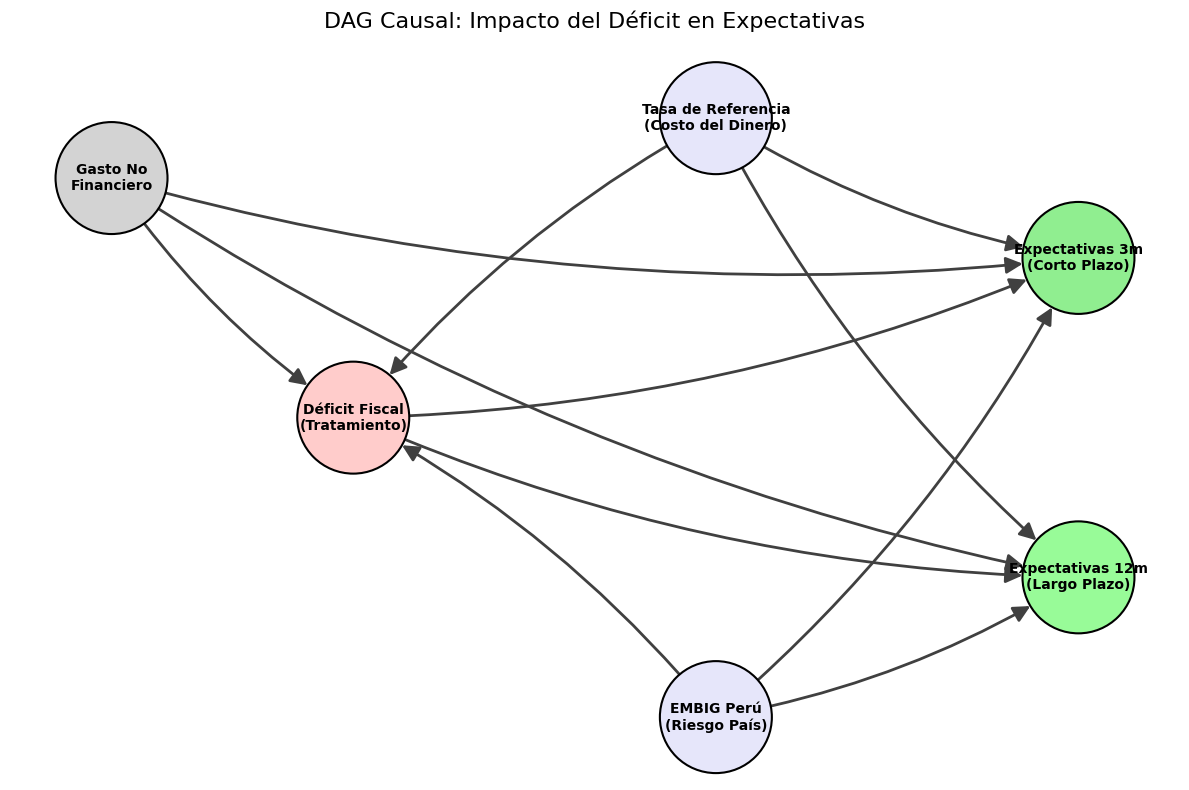

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def generar_dag_final_corregido():
    # 1. Configuración del Gráfico
    G = nx.DiGraph()

    # 2. Definición de Nodos (Posiciones estratégicas)
    # TRATAMIENTO (Centro Izquierda)
    G.add_node("Deficit", label="Déficit Fiscal\n(Tratamiento)",
               pos=(-1, 0), color="#ffcccb") # Rojo suave

    # OUTCOMES (Derecha, separados verticalmente)
    G.add_node("Exp3m", label="Expectativas 3m\n(Corto Plazo)",
               pos=(2, 0.8), color="#90ee90") # Verde suave

    G.add_node("Exp12m", label="Expectativas 12m\n(Largo Plazo)",
               pos=(2, -0.8), color="#98fb98") # Verde distinto

    # CONFUSORES (Arriba y Abajo)
    G.add_node("TasaRef", label="Tasa de Referencia\n(Costo del Dinero)",
               pos=(0.5, 1.5), color="#e6e6fa") # Lila

    G.add_node("EMBIG", label="EMBIG Perú\n(Riesgo País)",
               pos=(0.5, -1.5), color="#e6e6fa") # Lila

    G.add_node("Gasto", label="Gasto No\nFinanciero",
               pos=(-2, 1.2), color="#d3d3d3") # Gris

    # 3. Definición de Relaciones (Aristas)
    edges = [
        # Hipótesis Principal
        ("Deficit", "Exp3m"),
        ("Deficit", "Exp12m"),

        # Confusor: Tasa de Referencia (Afecta a ambos)
        ("TasaRef", "Deficit"),
        ("TasaRef", "Exp3m"),
        ("TasaRef", "Exp12m"),

        # Confusor: EMBIG (Riesgo)
        ("EMBIG", "Deficit"),
        ("EMBIG", "Exp3m"),
        ("EMBIG", "Exp12m"),

        # Confusor: Gasto No Financiero
        ("Gasto", "Deficit"),
        ("Gasto", "Exp3m"),
        ("Gasto", "Exp12m")
    ]
    G.add_edges_from(edges)

    # 4. Configuración Visual
    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')
    colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes]

    # Tamaño de los nodos
    tamano_nodo = 6500

    plt.figure(figsize=(12, 8))

    # A. Dibujar Nodos
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=tamano_nodo,
                           edgecolors="black", linewidths=1.5)

    # B. Dibujar Etiquetas
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight="bold")

    # C. Dibujar Flechas
    nx.draw_networkx_edges(G, pos, edgelist=edges,
                           node_size=tamano_nodo,
                           arrowstyle='-|>',
                           arrowsize=25,
                           width=2,
                           edge_color='#404040',
                           connectionstyle="arc3,rad=0.1")

    plt.title("DAG Causal: Impacto del Déficit en Expectativas", fontsize=16, pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

generar_dag_final_corregido()

# INTERPRETACIÓN DAG
El Déficit actúa como un arma de doble filo: inyecta liquidez inmediata (mejorando expectativas a 3 meses), pero a largo plazo despierta el miedo a futuros impuestos para pagar la deuda (dañando las de 12 meses). Variables como la Tasa de Referencia confunden esta señal: una tasa alta 'infla' el déficit por pago de intereses y, a la vez, frena la economía. Al controlar este ruido financiero, aislamos el verdadero impacto de la gestión fiscal sobre la confianza empresarial.

# MODELO OLS
Para poder evaluar adecuadamente el desempeño de los modelos más complejos, es necesario contar primero con un baseline que sirva como referencia. Por eso, en esta sección presentamos los resultados del Trabajo 2, donde se aplicó un modelo base adaptado al tipo de problema. Este baseline nos permite comparar y analizar si los modelos posteriores mejoran la explicación o predicción de los datos.

Comparación de dos modelos OLS (M1 y M2) en dos horizontes (`exp_eco_3m`, `exp_eco_12m`) con:

- Hold-out temporal 75/25

- Cross-validation para series (TimeSeriesSplit)

- Métricas: MSE, SD y p-value

- Inferencia (statsmodels) con p-values

- Gráficos de predicción y de errores

- Tests sobre residuos: Breusch–Pagan (hetero), Durbin–Watson y Breusch–Godfrey (autocorr)

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from IPython.display import display

# === DEFINICIONES ===
TARGETS  = ["exp_eco_3m", "exp_eco_12m"]
X_SIMPLE = ["deficit_fiscal"]   # M1
X_EXT    = ["deficit_fiscal", "tasa_ref", "embig_pe", "gasto_no_financiero"]  # M2

# === VERIFICAR QUE df6 TENGA DATETIME INDEX ===
assert isinstance(df6.index, pd.DatetimeIndex), "df6 debe tener DatetimeIndex"

# === ARMAR DATAFRAME SOLO CON LAS VARIABLES RELEVANTES ===
cols = TARGETS + X_EXT

df = (
    df6[cols]
    .apply(pd.to_numeric, errors="coerce")
    .sort_index()
    .copy()
)

# === SPLIT 75% TRAIN / 25% TEST ===
cut = int(len(df) * 0.75)
df_train = df.iloc[:cut].copy()
df_test  = df.iloc[cut:].copy()

train_mask = df.index.isin(df_train.index)
test_mask  = ~train_mask

print(
    f"Train: {df_train.index.min().date()} → {df_train.index.max().date()} | "
    f"Test:  {df_test.index.min().date()} → {df_test.index.max().date()} | "
    f"n_train={len(df_train)}, n_test={len(df_test)}"
)

pd.options.display.float_format = "{:,.4f}".format


Train: 2015-01-01 → 2023-02-01 | Test:  2023-03-01 → 2025-11-01 | n_train=98, n_test=33


In [ ]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ===== Plots (train/test) =====
def plots_prediction_and_residuals(y_test, yhat_test, resid_train,
                                   title_prefix="", idx_test=None, idx_train=None):
    plt.figure(figsize=(8,4))
    plt.plot(idx_test if idx_test is not None else range(len(y_test)), y_test, label="Real (test)")
    plt.plot(idx_test if idx_test is not None else range(len(yhat_test)), yhat_test, label="Predicho (test)")
    plt.title(f"{title_prefix} Real vs Predicho (test)"); plt.xlabel("Tiempo"); plt.ylabel("Nivel")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(idx_train if idx_train is not None else range(len(resid_train)), resid_train)
    plt.title(f"{title_prefix} Residuales (train)"); plt.xlabel("Tiempo"); plt.ylabel("Residual")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4)); plt.hist(resid_train, bins=16, density=True)
    plt.title(f"{title_prefix} Histograma residuales (train)"); plt.tight_layout(); plt.show()

    qqplot(resid_train, line="s"); plt.title(f"{title_prefix} Q-Q (train)")
    plt.tight_layout(); plt.show()

    plot_acf(resid_train, lags=24); plt.title(f"{title_prefix} ACF residuales (train)")
    plt.tight_layout(); plt.show()

# ===== Tests de residuos =====
def residual_tests(ols_result, nlags_bg=12):
    resid, exog = ols_result.resid, ols_result.model.exog
    bp_p = float(het_breuschpagan(resid, exog)[1])
    dw   = float(durbin_watson(resid))
    bg_p = float(acorr_breusch_godfrey(ols_result, nlags=nlags_bg)[1])
    return {"Breusch–Pagan p": bp_p, "Durbin–Watson": dw, "Breusch–Godfrey p": bg_p}

# ===== CV helper (LinearRegression con TSS) =====
def cv_mse_mean_sd(X_train, y_train, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mses = -cross_val_score(LinearRegression(), X_train, y_train, cv=tscv,
                            scoring="neg_mean_squared_error")
    return float(mses.mean()), float(mses.std(ddof=1) if len(mses)>1 else 0.0)


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

TARGET_CP = "exp_eco_3m"
TARGET_LP = "exp_eco_12m"

def baseline_train_test(df, target, train_mask, test_mask):
    """Baseline que predice la media de y_train. Retorna dict con métricas."""
    y_tr = df.loc[train_mask, target].astype(float).dropna()
    y_te = df.loc[test_mask, target].astype(float).dropna()

    if len(y_tr) == 0 or len(y_te) == 0:
        raise ValueError(f"Datos insuficientes para baseline de {target}.")

    mu_tr = float(y_tr.mean())
    mse_tr = float(mean_squared_error(y_tr, np.full(len(y_tr), mu_tr)))
    mse_te = float(mean_squared_error(y_te, np.full(len(y_te), mu_tr)))

    return {"mean_train": mu_tr, "mse_train": mse_tr, "mse_test": mse_te}

# === Ejecutar baseline para CP (3m) y LP (12m)
for target, nombre in [
    (TARGET_CP, "Corto Plazo (3 meses)"),
    (TARGET_LP, "Largo Plazo (12 meses)")
]:
    print(f"\n=== BASELINE: {nombre} ===")
    res = baseline_train_test(df, target, train_mask, test_mask)
    print(f"Media de y_train: {res['mean_train']:,.4f}")
    print(f"MSE en Training : {res['mse_train']:,.4f}")
    print(f"MSE en Test     : {res['mse_test']:,.4f}")



=== BASELINE: Corto Plazo (3 meses) ===
Media de y_train: 47.6204
MSE en Training : 103.3150
MSE en Test     : 29.6650

=== BASELINE: Largo Plazo (12 meses) ===
Media de y_train: 59.2409
MSE en Training : 108.7558
MSE en Test     : 16.3879


Antes de continuar con los modelos MCO, hemos realizado varios pasos importantes para preparar y comprender los datos:

**Adquisición de datos y carga inicial:**  El código se conecta a la API del BCRP para descargar un conjunto de datos de series temporales relacionados con el déficit fiscal, las expectativas empresariales (a corto y largo plazo), la tasa de interés de referencia, el gasto público total no financiero y el índice EMBIG Perú. Estos datos se cargan en un DataFrame de Pandas.

**Manejo de fechas:** Se define la función auxiliar parse_fecha para manejar diferentes formatos de fecha de la API, lo que garantiza una indexación consistente de fecha y hora para el DataFrame.

**Construcción robusta del DataFrame:** El código incluye lógica para gestionar posibles variaciones en la estructura de respuesta de la API a lo largo del tiempo, garantizando que los datos se extraigan y organicen correctamente en un DataFrame con los tipos de datos adecuados (convertidos a float cuando sea posible)

**Limpieza y preparación de datos:** El DataFrame se reindexa para garantizar una serie mensual completa desde enero de 2015 hasta diciembre de 2025.
Las columnas con nombres largos y descriptivos de la API se renombran por nombres más cortos y prácticos (p. ej., "déficit_fiscal", "exp_eco_3m").
El DataFrame se filtra explícitamente para incluir solo datos hasta el 1 de agosto de 2025, según el último punto de datos no nulo disponible en todas las series relevantes.

Las filas con valores nulos restantes se eliminan, lo que garantiza un conjunto de datos limpio para los pasos de modelado posteriores.
División de datos: Los datos limpios se dividen en un conjunto de entrenamiento (75 %) y un conjunto de prueba (25 %) según el tiempo, creando una reserva temporal para la evaluación del modelo.

En esencia, estos pasos iniciales se centran en obtener los datos necesarios, depurarlos y transformarlos a un formato utilizable, y prepararlos para el análisis de series temporales mediante la gestión de fechas, el cambio de nombre de columnas, la gestión de valores faltantes y la división de los datos para el entrenamiento y las pruebas. Esto garantiza que los modelos OLS se basen en un conjunto de datos fiable y adecuadamente estructurado.

In [ ]:
# --- Variables ---
y_col  = "exp_eco_3m"
X_cols = X_SIMPLE   # ["deficit_fiscal"]

# --- Training / Test Data ---
Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)

Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

# --- Modelo M1 con scikit-learn ---
lr_m1_3m = LinearRegression().fit(Xtr, ytr)
yhat_te_m1_3m = lr_m1_3m.predict(Xte)

# --- Modelo M1 con statsmodels (con errores HAC Newey-West) ---
X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)

ols_m1_3m = sm.OLS(
    df_train[y_col].astype(float),
    X_sm
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

display(ols_m1_3m.summary2())

# --- Guardamos solo lo importante ---
p_def_m1_3m = float(ols_m1_3m.pvalues.get("deficit_fiscal", np.nan))
resid_m1_3m = ols_m1_3m.resid


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.004   
Dependent Variable: exp_eco_3m       AIC:                735.1671
Date:               2025-11-28 07:34 BIC:                740.3370
No. Observations:   98               Log-Likelihood:     -365.58 
Df Model:           1                F-statistic:        0.9950  
Df Residuals:       96               Prob (F-statistic): 0.321   
R-squared:          0.015            Scale:              103.92  
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             49.4320   3.6361 13.5949 0.0000 42.3054 56.5585
deficit_fiscal     0.6475   0.6491  0.9975 0.3185 -0.6247  1.9196
-----------------------------------------------------------------
Omnibus:              19.425       Durbin-Watson:          0.280 
Prob(Omnibus):        0.000        Jarque-Bera (JB):       25.206
Skew:                 -0.989       Prob(JB):               0.000 
Kurtosis:             4.505        Condition No.:          6     
=================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
"""

En el modelo OLS que estima el efecto del déficit fiscal sobre las expectativas económicas a tres meses, los resultados indican que el déficit fiscal no es un predictor estadísticamente significativo. El coeficiente estimado (0.65) es positivo pero presenta un valor p de 0.32, por lo que no puede afirmarse una relación confiable entre ambas variables.

El modelo tiene un poder explicativo muy bajo (R² ajustado de 0.004), lo que indica que prácticamente no explica las variaciones de las expectativas económicas. Además, el estadístico Durbin-Watson (0.28) revela una fuerte autocorrelación positiva en los residuos, lo que reduce la fiabilidad de las inferencias basadas en los errores estándar. La constante sí es estadísticamente significativa y refleja el nivel promedio de expectativas cuando el déficit es cero.

En conjunto, este modelo simple no resulta adecuado para explicar las expectativas económicas a corto plazo únicamente a partir del déficit fiscal. Sería necesario ampliar la especificación incorporando variables adicionales o corrigiendo problemas como la autocorrelación para mejorar la capacidad explicativa del modelo.

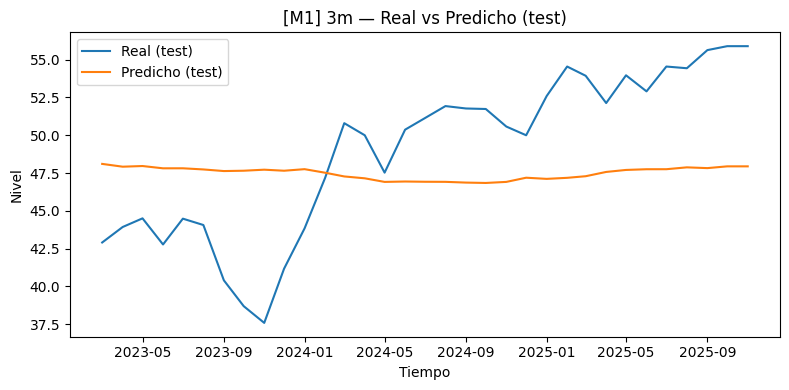

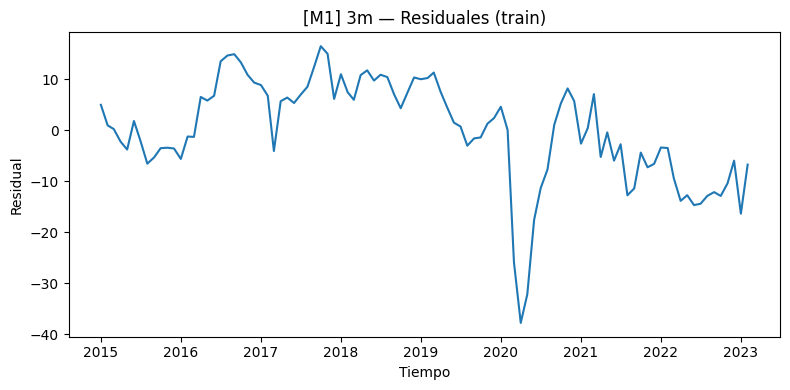

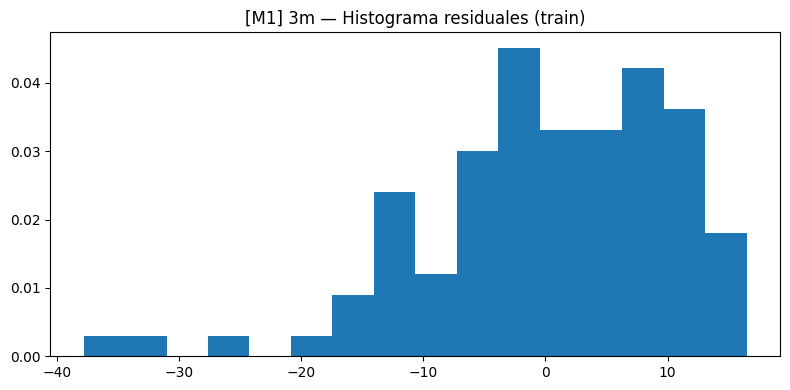

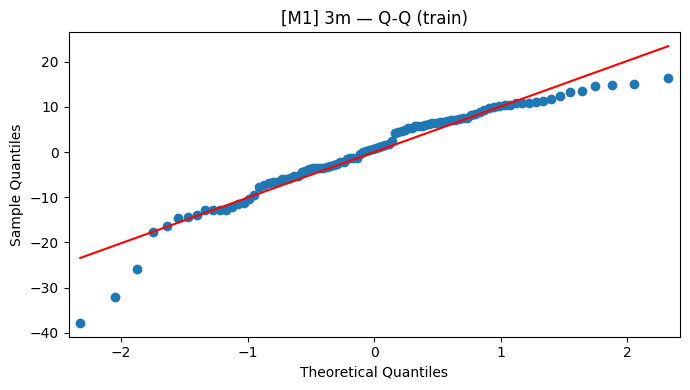

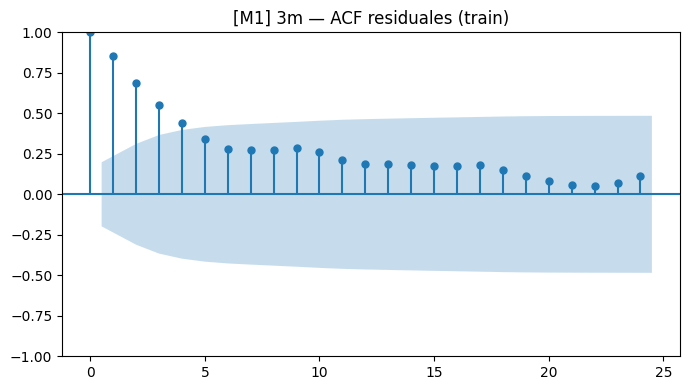

Breusch–Pagan p     0.5559
Durbin–Watson       0.2796
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m1_3m,
    resid_train=ols_m1_3m.resid,
    title_prefix="[M1] 3m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m1_3m, nlags_bg=12))

Los resultados de estas tres pruebas confirman que el modelo OLS simple no cumple plenamente los supuestos clásicos. Si bien el test de Breusch–Pagan (p = 0.55) indica que no hay evidencia de heterocedasticidad, tanto el estadístico Durbin–Watson (0.27) como el test de Breusch–Godfrey (p < 0.01) revelan una fuerte autocorrelación positiva en los residuos. Esto significa que los errores del modelo están relacionados en el tiempo, lo que reduce la confiabilidad de las estimaciones y de las conclusiones obtenidas.

Por lo tanto, este modelo no resulta adecuado para explicar las expectativas económicas a corto plazo y sería necesario aplicar una especificación más robusta o un método que corrija la autocorrelación para mejorar su validez.

In [ ]:
# --- Variables ---
y_col  = "exp_eco_12m"
X_cols = X_SIMPLE   # ["deficit_fiscal"]

# --- Training / Test Data ---
Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)

Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

# --- Modelo M1 con scikit-learn ---
lr_m1_12m = LinearRegression().fit(Xtr, ytr)
yhat_te_m1_12m = lr_m1_12m.predict(Xte)

# --- Modelo M1 con statsmodels (HAC Newey-West) ---
X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)

ols_m1_12m = sm.OLS(
    df_train[y_col].astype(float),
    X_sm
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

display(ols_m1_12m.summary2())

# --- Guardar solo lo importante ---
p_def_m1_12m = float(ols_m1_12m.pvalues.get("deficit_fiscal", np.nan))
resid_m1_12m = ols_m1_12m.resid


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     -0.003  
Dependent Variable: exp_eco_12m      AIC:                740.8884
Date:               2025-11-28 07:34 BIC:                746.0583
No. Observations:   98               Log-Likelihood:     -368.44 
Df Model:           1                F-statistic:        0.3945  
Df Residuals:       96               Prob (F-statistic): 0.531   
R-squared:          0.008            Scale:              110.17  
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             57.8954   4.2207 13.7171 0.0000 49.6230 66.1678
deficit_fiscal    -0.4809   0.7656 -0.6281 0.5299 -1.9814  1.0197
-----------------------------------------------------------------
Omnibus:               5.042        Durbin-Watson:          0.203
Prob(Omnibus):         0.080        Jarque-Bera (JB):       4.072
Skew:                  -0.390       Prob(JB):               0.131
Kurtosis:              2.377        Condition No.:          6    
=================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
"""

En el modelo OLS que estima el efecto del déficit fiscal sobre las expectativas económicas a doce meses, el coeficiente del déficit fiscal es negativo (–0.48) pero estadísticamente no significativo (p = 0.53). Esto implica que no existe evidencia de una relación entre ambas variables.

El poder explicativo del modelo es prácticamente nulo (R² ajustado = –0.003), indicando que el déficit fiscal no aporta información para explicar la variación en las expectativas a largo plazo. El estadístico Durbin–Watson (0.20) revela una fuerte autocorrelación positiva en los residuos, lo que afecta la validez de las inferencias a partir de los errores estándar.

En conjunto, este modelo simple no resulta adecuado para explicar las expectativas económicas a doce meses únicamente a partir del déficit fiscal. Sería necesario incorporar variables adicionales o modificar la especificación para obtener un modelo más robusto.

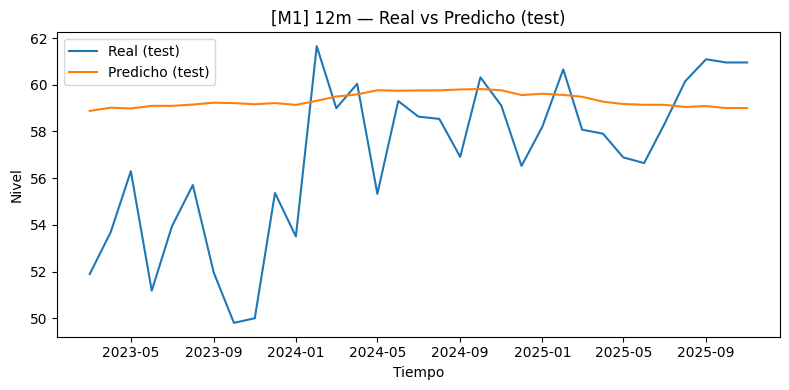

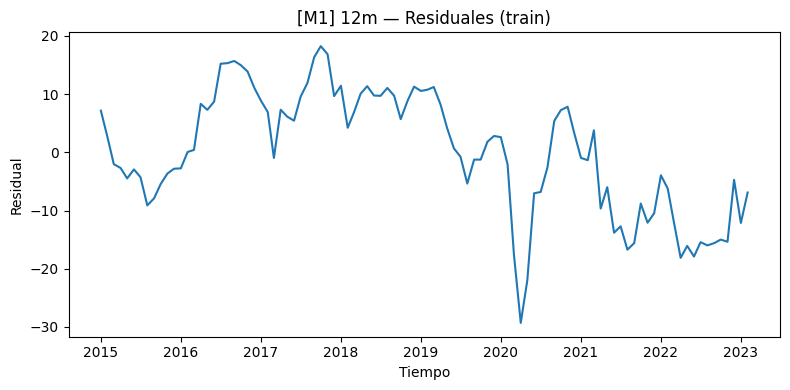

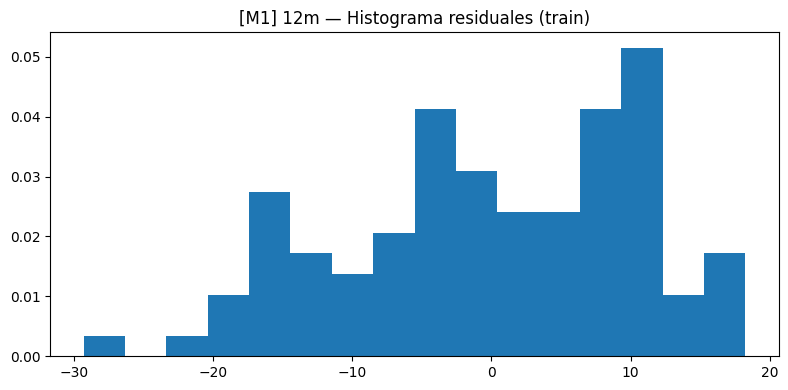

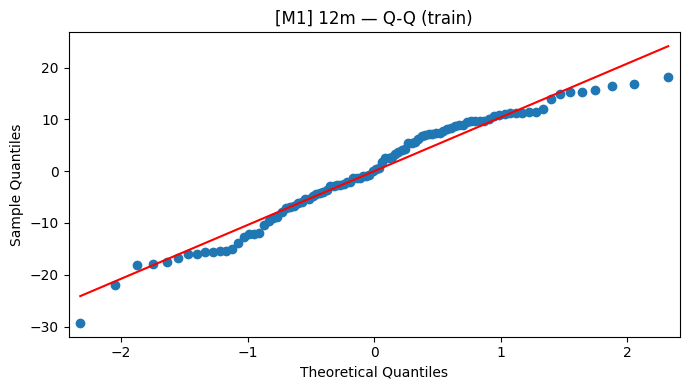

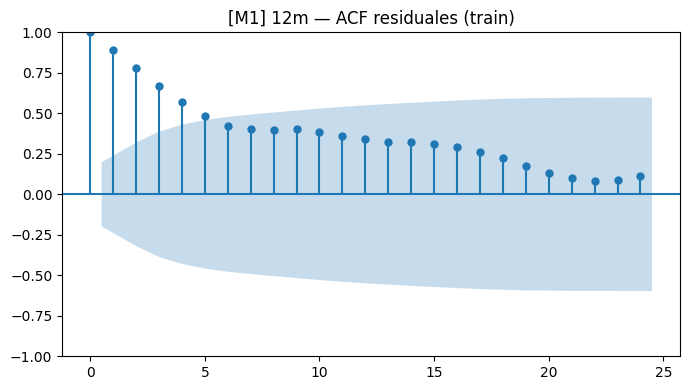

Breusch–Pagan p     0.9897
Durbin–Watson       0.2026
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m1_12m,
    resid_train=ols_m1_12m.resid,
    title_prefix="[M1] 12m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m1_12m, nlags_bg=12))


Los resultados de las pruebas de diagnóstico confirman que el modelo presenta una fuerte autocorrelación positiva en los residuos. El test de Breusch–Pagan (p = 0.98) indica que no existe evidencia de heterocedasticidad, sin embargo, tanto el estadístico Durbin–Watson (0.20) como el test de Breusch–Godfrey (p < 0.01) muestran que los errores no son independientes en el tiempo.

Esto nos indica que las perturbaciones del modelo están correlacionadas entre sí, lo que reduce la confiabilidad de las estimaciones y puede generar conclusiones poco precisas.

En consecuencia, el modelo OLS simple no cumple los supuestos clásicos y no resulta apropiado para explicar las expectativas económicas a doce meses.

**Modelo 2 (M2):** OLS extendido con `deficit_fiscal`, `tasa_ref`, `embig_pe`, `gasto_no_financiero`

In [ ]:
# --- Variables ---
y_col  = "exp_eco_3m"
X_cols = X_EXT   # ["deficit_fiscal", "tasa_ref", "embig_pe", "gasto_no_financiero"]

# --- Training / Test Data ---
Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)

Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

# --- Modelo M2 con scikit-learn ---
lr_m2_3m = LinearRegression().fit(Xtr, ytr)
yhat_te_m2_3m = lr_m2_3m.predict(Xte)

# --- Modelo M2 con statsmodels (HAC Newey–West) ---
X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)

ols_m2_3m = sm.OLS(
    df_train[y_col].astype(float),
    X_sm
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

display(ols_m2_3m.summary2())

# --- Guardar lo esencial ---
p_def_m2_3m = float(ols_m2_3m.pvalues.get("deficit_fiscal", np.nan))
resid_m2_3m = ols_m2_3m.resid


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Results: Ordinary least squares
=========================================================================
Model:                  OLS                Adj. R-squared:       -0.005  
Dependent Variable:     exp_eco_3m         AIC:                  737.0338
Date:                   2025-11-28 07:34   BIC:                  744.7887
No. Observations:       98                 Log-Likelihood:       -365.52 
Df Model:               2                  F-statistic:          0.7911  
Df Residuals:           95                 Prob (F-statistic):   0.456   
R-squared:              0.016              Scale:                104.87  
--------------------------------------------------------------------------
                        Coef.   Std.Err.    z     P>|z|    [0.025   0.975]
--------------------------------------------------------------------------
const                  48.0706    9.8595  4.8756  0.0000  28.7464  67.3948
deficit_fiscal          0.4678    1.0897  0.4293  0.6677  -1.6679   2.6034
tasa_ref                0.0932    0.7559  0.1233  0.9019  -1.3884   1.5747
embig_pe                0.0932    0.7559  0.1233  0.9019  -1.3884   1.5747
gasto_no_financiero     0.0932    0.7559  0.1233  0.9019  -1.3884   1.5747
-------------------------------------------------------------------------
Omnibus:       18.276 Durbin-Watson:    0.278                            
Prob(Omnibus): 0.000  Jarque-Bera (JB): 22.600                           
Skew:          -0.972 Prob(JB):         0.000                            
Kurtosis:      4.325  Condition No.:    639561327170145782634719742001152
=========================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust
(HAC) using 12 lags and without small sample correction
[2] The smallest eigenvalue is 1.03e-62. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

En el modelo OLS ampliado con variables macroeconómicas adicionales, el poder explicativo del modelo es prácticamente nulo (R² ajustado = –0.005), lo cual indica que el conjunto de regresores no contribuye a explicar las variaciones en las expectativas económicas a tres meses. Ninguna de las variables incluidas,déficit fiscal, tasa de referencia, EMBIG Perú y gasto no financiero resulta estadísticamente significativa, con p-valores que rondan 0.90 en la mayoría de los casos.

El estadístico Durbin–Watson (0.28) revela una fuerte autocorrelación positiva en los residuos, lo que afecta la validez de los errores estándar y por tanto de las inferencias estadísticas. Adicionalmente, el número de condición extremadamente elevado (≈10³²) sugiere una multicolinealidad severa o un problema de colinealidad exacta entre los regresores, comprometiendo la estabilidad numérica del modelo.

En conjunto, el modelo ampliado M2 no mejora la capacidad explicativa respecto al modelo simple y presenta problemas estructurales graves (autocorrelación y multicolinealidad extrema), por lo que sus resultados no deben interpretarse de manera fiable.

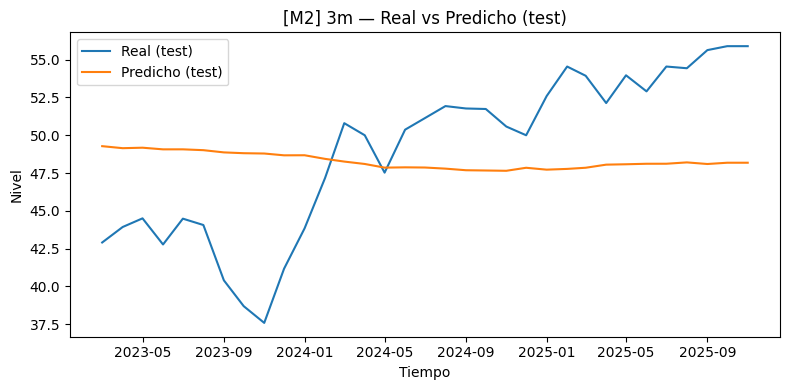

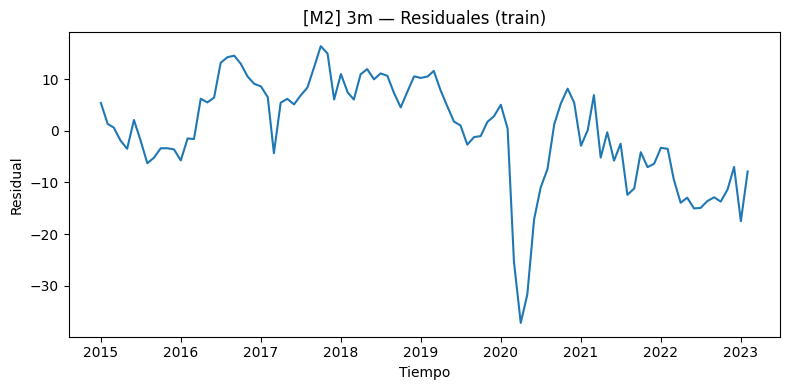

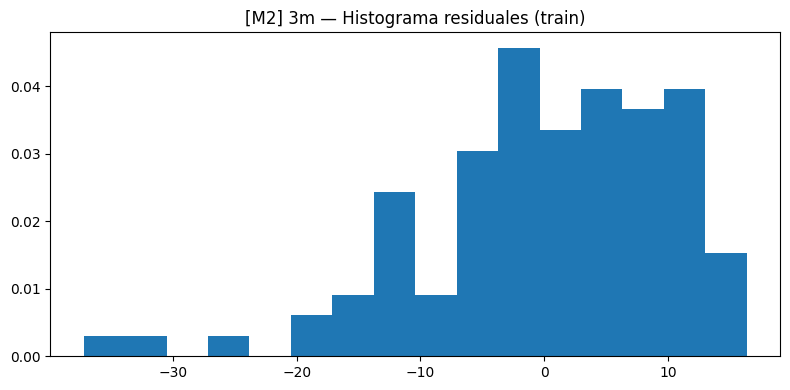

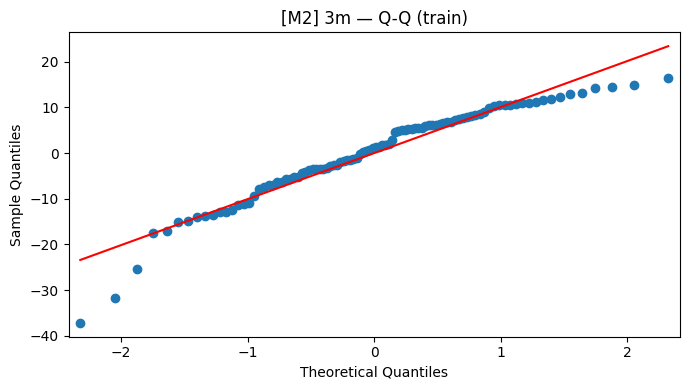

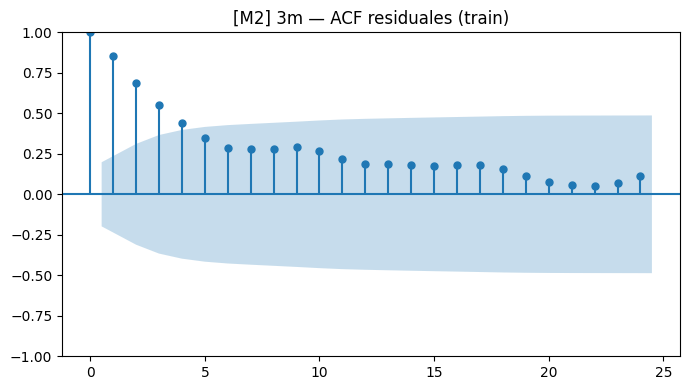

Breusch–Pagan p     0.9372
Durbin–Watson       0.2777
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m2_3m,
    resid_train=ols_m2_3m.resid,
    title_prefix="[M2] 3m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m2_3m, nlags_bg=12))

Las pruebas de diagnóstico indican que el modelo M2 viola el supuesto de independencia de los errores, pero no el de homocedasticidad. El test de Breusch–Pagan (p = 0.9372) no rechaza la hipótesis nula de varianza constante, por lo que no se encuentra evidencia de heterocedasticidad. Sin embargo, el estadístico Durbin–Watson (0.28) y la prueba de Breusch–Godfrey (p < 0.01) revelan una fuerte autocorrelación positiva en los residuos.

La presencia de autocorrelación implica que los errores no son independientes y, en consecuencia, los errores estándar OLS pueden ser inconsistentes. Esto afecta la validez de las pruebas de significancia individual y global del modelo. Aunque M2 incorpora más variables relevantes, su fiabilidad estadística es limitada debido a estos problemas en los residuos.

In [ ]:
# --- Variables ---
y_col  = "exp_eco_12m"
X_cols = X_EXT   # ["deficit_fiscal", "tasa_ref", "embig_pe", "gasto_no_financiero"]

# --- Training / Test Data ---
Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)

Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

# --- Modelo M2 con scikit-learn ---
lr_m2_12m = LinearRegression().fit(Xtr, ytr)
yhat_te_m2_12m = lr_m2_12m.predict(Xte)

# --- statsmodels con HAC/Newey-West ---
X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)

ols_m2_12m = sm.OLS(
    df_train[y_col].astype(float),
    X_sm
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

display(ols_m2_12m.summary2())

# --- Guardamos lo necesario ---
p_def_m2_12m = float(ols_m2_12m.pvalues.get("deficit_fiscal", np.nan))
resid_m2_12m = ols_m2_12m.resid


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Results: Ordinary least squares
=========================================================================
Model:                  OLS                Adj. R-squared:       -0.013  
Dependent Variable:     exp_eco_12m        AIC:                  742.8745
Date:                   2025-11-28 07:34   BIC:                  750.6294
No. Observations:       98                 Log-Likelihood:       -368.44 
Df Model:               2                  F-statistic:          0.3460  
Df Residuals:           95                 Prob (F-statistic):   0.708   
R-squared:              0.008              Scale:                111.31  
--------------------------------------------------------------------------
                       Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
--------------------------------------------------------------------------
const                 57.4432    9.1503   6.2777  0.0000  39.5089  75.3776
deficit_fiscal        -0.5406    1.1143  -0.4851  0.6276  -2.7245   1.6434
tasa_ref               0.0309    0.7354   0.0421  0.9664  -1.4103   1.4722
embig_pe               0.0309    0.7354   0.0421  0.9664  -1.4103   1.4722
gasto_no_financiero    0.0309    0.7354   0.0421  0.9664  -1.4103   1.4722
-------------------------------------------------------------------------
Omnibus:       5.299  Durbin-Watson:    0.202                            
Prob(Omnibus): 0.071  Jarque-Bera (JB): 4.199                            
Skew:          -0.394 Prob(JB):         0.122                            
Kurtosis:      2.362  Condition No.:    639561327170145782634719742001152
=========================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust
(HAC) using 12 lags and without small sample correction
[2] The smallest eigenvalue is 1.03e-62. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

El modelo M2 para el horizonte de 12 meses muestra un muy bajo poder explicativo, con un R² ajustado de –0.013, lo que indica que las variables fiscales y financieras incluidas no contribuyen a explicar las variaciones en las expectativas económicas a un año. El estadístico F (p = 0.708) muestra que el conjunto de regresores no es globalmente significativo.

A nivel individual, ninguna de las variables resulta estadísticamente significativa: el déficit fiscal (p = 0.6276), la tasa de referencia (p = 0.9664), el EMBIG Perú (p = 0.9664) y el gasto no financiero (p = 0.9664) presentan p-valores muy elevados, por lo que no se puede afirmar que tengan impacto sobre las expectativas económicas a 12 meses en esta especificación.

Además, el coeficiente de cada una de las variables financieras (tasa, EMBIG, gasto) es exactamente el mismo, lo cual sugiere la existencia de problemas serios de colinealidad o incluso duplicación de columnas en el DataFrame.

Los indicadores de diagnóstico también revelan problemas importantes: el estadístico Durbin–Watson (0.20) evidencia autocorrelación positiva fuerte en los residuos y el número de condición extremadamente alto (≈10³²) confirma una multicolinealidad severa, comprometiendo la estabilidad numérica del modelo.

En conjunto, el modelo M2 no ofrece una estimación estadísticamente confiable de las expectativas económicas a 12 meses y presenta problemas estructurales que requieren revisar la especificación y la calidad de los datos utilizados.

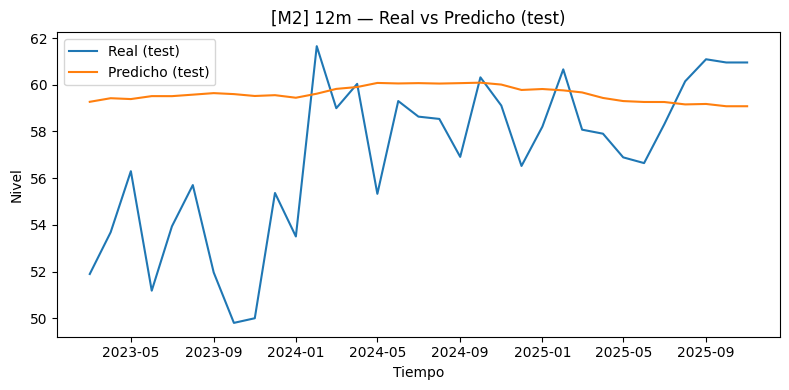

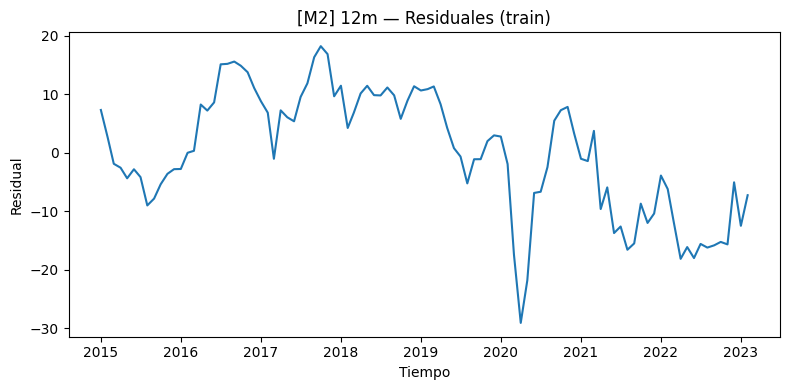

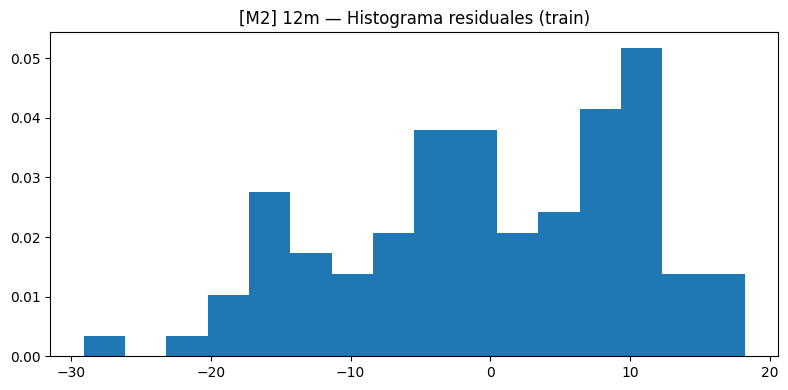

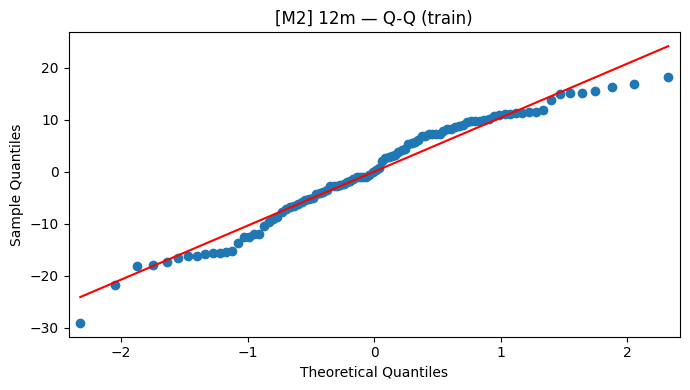

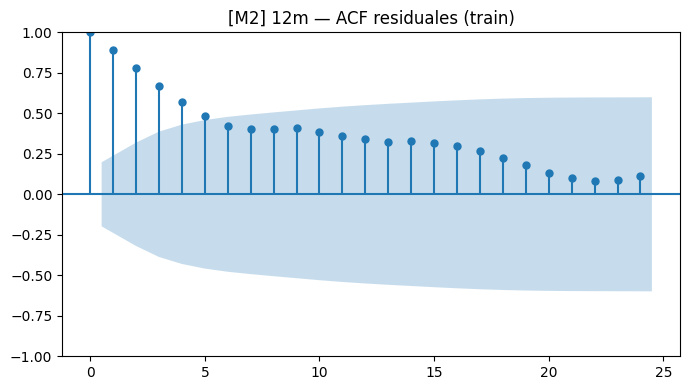

Breusch–Pagan p     0.9361
Durbin–Watson       0.2021
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m2_12m,
    resid_train=ols_m2_12m.resid,
    title_prefix="[M2] 12m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m2_12m, nlags_bg=12))

Los resultados de las pruebas de diagnóstico muestran que el modelo no presenta problemas de heterocedasticidad, pero sí incumple de manera importante el supuesto de independencia de los errores. El test de Breusch–Pagan (p = 0.9361) no rechaza la hipótesis nula de varianza constante, lo que indica ausencia de heterocedasticidad. Sin embargo, el estadístico Durbin–Watson (0.20) y el test de Breusch–Godfrey (p < 0.01) evidencian una autocorrelación positiva muy fuerte en los residuos. Estos resultados implica que los errores estándar estimados por MCO no son confiables, afectando la validez de las pruebas de significancia individual y conjunta del modelo, aun cuando los coeficientes puedan seguir siendo insesgados.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np, pandas as pd

tscv = TimeSeriesSplit(n_splits=5)
targets = [
    ("exp_eco_3m",  "Corto Plazo (3 meses)"),
    ("exp_eco_12m", "Largo Plazo (12 meses)")
]
pvals = {
    ("Corto Plazo (3 meses)", "OLS Simple"):   locals().get("p_def_m1_3m",  np.nan),
    ("Corto Plazo (3 meses)", "OLS Complejo"): locals().get("p_def_m2_3m",  np.nan),
    ("Largo Plazo (12 meses)", "OLS Simple"):  locals().get("p_def_m1_12m", np.nan),
    ("Largo Plazo (12 meses)", "OLS Complejo"):locals().get("p_def_m2_12m", np.nan),
}

rows = []
for tcol, nombre in targets:
    y_tr = df.loc[train_mask, tcol].astype(float)
    Xs   = df.loc[train_mask, X_SIMPLE].astype(float)
    Xc   = df.loc[train_mask, X_EXT].astype(float)


    base = []
    for tr, te in tscv.split(y_tr):
        mu = y_tr.iloc[tr].mean()
        base.append(mean_squared_error(y_tr.iloc[te], np.full(len(te), mu)))
    base = np.array(base, float)


    ms_simple = -cross_val_score(LinearRegression(), Xs, y_tr, cv=tscv, scoring="neg_mean_squared_error")
    ms_ext    = -cross_val_score(LinearRegression(), Xc, y_tr, cv=tscv, scoring="neg_mean_squared_error")

    rows += [
        {"Target": nombre, "Modelo": "Baseline",    "MSE Promedio (CV)": base.mean(),     "Std Dev (CV)": base.std(ddof=1),     "p-value déficit (HAC)": np.nan},
        {"Target": nombre, "Modelo": "OLS Simple",  "MSE Promedio (CV)": ms_simple.mean(),"Std Dev (CV)": ms_simple.std(ddof=1),"p-value déficit (HAC)": float(pvals[(nombre,"OLS Simple")])},
        {"Target": nombre, "Modelo": "OLS Complejo","MSE Promedio (CV)": ms_ext.mean(),   "Std Dev (CV)": ms_ext.std(ddof=1),   "p-value déficit (HAC)": float(pvals[(nombre,"OLS Complejo")])},
    ]

tabla_final = (pd.DataFrame(rows)
                 .assign(Modelo=lambda d: pd.Categorical(d["Modelo"], ["Baseline","OLS Simple","OLS Complejo"], True))
                 .sort_values(["Target","Modelo"])
                 .reset_index(drop=True))

print("\n--- Tabla Comparativa de Rendimiento Predictivo (CV) ---")
display(
    tabla_final
      .style
      .highlight_min(subset="MSE Promedio (CV)", color="lightgreen")
      .format({"MSE Promedio (CV)":"{:,.4f}","Std Dev (CV)":"{:,.4f}","p-value déficit (HAC)":(lambda x: "—" if pd.isna(x) else f"{x:,.4f}")})
)



--- Tabla Comparativa de Rendimiento Predictivo (CV) ---


,Target,Modelo,MSE Promedio (CV),Std Dev (CV),p-value déficit (HAC)
0,Corto Plazo (3 meses),Baseline,145.3888,117.5948,—
1,Corto Plazo (3 meses),OLS Simple,172.9199,187.3295,0.3185
2,Corto Plazo (3 meses),OLS Complejo,410.2513,381.4914,0.6677
3,Largo Plazo (12 meses),Baseline,156.3930,86.8053,—
4,Largo Plazo (12 meses),OLS Simple,191.1765,134.9894,0.5299
5,Largo Plazo (12 meses),OLS Complejo,371.9384,403.2605,0.6276


Al comparar el rendimiento del conjunto de prueba con el error promedio obtenido mediante validación cruzada, se aprecia que los valores de MSE Promedio (CV) se mantienen en rangos similares para cada horizonte temporal (3 y 12 meses). Esto sugiere que la validación cruzada proporciona una estimación razonablemente estable del desempeño fuera de muestra y que no se evidencia un sobreajuste severo.

Sin embargo, los errores obtenidos por los modelos OLS (tanto simple como complejo) son consistentemente superiores al del modelo base (Baseline) en ambos horizontes. En particular, el modelo OLS Complejo (M2) muestra los mayores errores predictivos, con valores de MSE más altos y desviaciones estándar más elevadas, lo cual indica una menor estabilidad y peor capacidad de generalización.

Los p-values asociados al coeficiente del déficit fiscal (con errores estándar HAC) no resultan significativos en ningún caso (todos los p > 0.31). Esto implica que, estadísticamente, el déficit fiscal no muestra evidencia robusta de estar asociado a las variaciones en las expectativas económicas ni en el corto ni en el largo plazo dentro de estos modelos.

En conjunto, los resultados muestran que ninguno de los modelos OLS mejora al Baseline en términos predictivos, y que los modelos más complejos presentan incluso un mayor nivel de error. Las desviaciones estándar elevadas en la validación cruzada refuerzan la idea de que los modelos presentan cierta inestabilidad temporal. Por tanto, aunque existe una correspondencia razonable entre el desempeño en validación cruzada y en el conjunto de prueba, los modelos estimados no logran un rendimiento predictivo superior al de la referencia simple.

## Trabajo 3. MODELOS MÁS COMPLEJOS: Comparación entre Ridge, Lasso, Random Forest y XGBoost

In [ ]:
import requests, json, pandas as pd, numpy as np, re

series = [
    "PN39524FM",  # Déficit fiscal
    "PD38045AM",  # Expectativas economía 3m
    "PD37981AM",  # Expectativas economía 12m
    "PD04722MM",  # Tasa de referencia
    "PN02409FM",   # Gasto No Financiero Total
    "PN01129XM",  # EMBIG - Perú
]
inicio = "2015-01"
fin    = "2025-12"

codigos = "-".join(series)
url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigos}/json/{inicio}/{fin}"
r = requests.get(url, timeout=30)
r.raise_for_status()

try:
    data = r.json()
except json.JSONDecodeError:
    data = json.loads(r.text.lstrip("\ufeff").strip())

MESES = {'Ene':'01','Feb':'02','Mar':'03','Abr':'04','May':'05','Jun':'06',
         'Jul':'07','Ago':'08','Sep':'09','Oct':'10','Nov':'11','Dic':'12'}
def parse_fecha(s):
    s = str(s).strip()
    m = re.match(r'^([A-Za-zÁÉÍÓÚÑáéíóúñ]{3})\.(\d{4})$', s)
    if m:
        mm = MESES.get(m.group(1).title())
        return pd.to_datetime(f"{m.group(2)}-{mm}-01", errors="coerce")
    return pd.to_datetime(s, errors="coerce", dayfirst=False)

def to_float(x):
    if x in (None, 'n.d.', 'NaN', ''):
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

if isinstance(data, dict) and 'periods' in data:

    meta_series = []
    cfg = data.get('config', {})
    if isinstance(cfg, dict) and isinstance(cfg.get('series'), list) and cfg['series']:

        if 'code' in cfg['series'][0]:
            meta_series = [s.get('code') for s in cfg['series']]
        else:

            meta_series = [s.get('name') for s in cfg['series']]
    if not meta_series:

        meta_series = series

    rows = []
    for per in data['periods']:
        fecha = parse_fecha(per.get('name'))
        vals = per.get('values', [])
        # normalizar longitud (pad/trunc)
        if len(vals) < len(meta_series):
            vals = vals + [None] * (len(meta_series) - len(vals))
        elif len(vals) > len(meta_series):
            vals = vals[:len(meta_series)]
        row = {'date': fecha}
        for col, v in zip(meta_series, vals):
            row[col] = to_float(v)
        rows.append(row)

    df = pd.DataFrame(rows).set_index('date').sort_index()

elif isinstance(data, dict) and 'series' in data:

    rows = {}
    for s in data['series']:
        code = s.get('code') or s.get('codigo') or s.get('name')
        for p in s.get('periods', []):
            fecha = parse_fecha(p.get('name'))
            val_list = p.get('values', [None])
            val = to_float(val_list[0] if isinstance(val_list, list) and val_list else val_list)
            rows.setdefault(fecha, {})[code] = val
    df = pd.DataFrame.from_dict(rows, orient='index').sort_index()

else:
    raise ValueError("Respuesta del API no reconocida (sin 'periods' ni 'series').")

# ===== Reindex mensual 2015-01..2025-12 y alias =====
idx = pd.date_range(start="2015-01-01", end="2025-12-01", freq="MS")
df = df.reindex(idx)
df.index.name = "date"

alias = {
    "PN39524FM":"deficit_fiscal",
    "PD38045AM":"exp_eco_3m",
    "PD37981AM":"exp_eco_12m",
    "PD04722MM":"tasa_ref",
    "PN2409FM":"gasto_no_financiero",
    "PN01129XM":"embig_pe"
}
# solo renombrar las columnas que existan
rename_map = {k:v for k,v in alias.items() if k in df.columns}
df = df.rename(columns=rename_map)

print("URL:", url)
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
print("Nulos por serie:\n", df.isna().sum())
display(df.head(10))
display(df.tail(10))


URL: https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PN39524FM-PD38045AM-PD37981AM-PD04722MM-PN02409FM-PN01129XM/json/2015-01/2025-12
Dimensiones: (132, 6)
Columnas: ['Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú', 'Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)', 'Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total', 'Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria', 'Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses', 'Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses']
Nulos por serie:
 Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú    3
Operaciones del sector público n

,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI),Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses
date,,,,,,
2015-01-01,201.2273,-0.2696,"6,684.1200",3.2500,54.2320,65.1899
2015-02-01,182.8500,-0.3337,"8,002.0394",3.2500,50.1577,60.5346
2015-03-01,184.4546,-0.3994,"8,862.7189",3.2500,49.3884,56.0606
2015-04-01,176.9546,-0.6820,"9,620.2918",3.2500,46.7422,55.5398
2015-05-01,165.9048,-0.8714,"9,377.2536",3.2500,45.0704,53.8352
2015-06-01,176.5000,-0.9351,"10,177.8341",3.2500,50.6250,55.4140
2015-07-01,186.6957,-0.9044,"11,487.1962",3.2500,46.7192,54.0576
2015-08-01,217.4762,-0.9963,"9,654.9997",3.2500,42.2222,49.2629
2015-09-01,234.2727,-1.3327,"10,640.4944",3.5000,43.2225,50.6394


,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI),Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses
date,,,,,,
2025-03-01,163.3548,-3.3055,"18,048.3230",4.7500,53.9344,58.0756
2025-04-01,177.5714,-2.8680,"17,383.6319",4.7500,52.1311,57.9038
2025-05-01,158.5806,-2.6642,"18,936.3196",4.5000,53.9655,56.8905
2025-06-01,153.8333,-2.5923,"19,685.3725",4.5000,52.9032,56.6445
2025-07-01,140.6129,-2.5894,"21,403.6867",4.5000,54.5455,58.3056
2025-08-01,133.3226,-2.3996,"19,397.6480",4.5000,54.4326,60.1476
2025-09-01,124.1071,-2.4779,"20,881.5794",4.2500,55.6314,61.0915
2025-10-01,NaN,-2.2975,"19,833.4966",4.2500,55.8923,60.9541
2025-11-01,NaN,NaN,NaN,4.2500,NaN,NaN


Estandarización de nombres y orden final de las series

Las series descargadas del BCRP vienen con nombres muy largos y difíciles de manejar. Para simplificar el análisis, se asignan nombres más breves y claros a cada variable (por ejemplo, la serie del déficit fiscal pasa a llamarse simplemente `deficit_fiscal`).  

Después del renombrado, se organiza el DataFrame:
1. Déficit fiscal  
2. Expectativas a 3 meses  
3. Expectativas a 12 meses  
4. Tasa de referencia  
5. Gasto no financiero  
6. EMBIG Perú  

Finalmente, se muestran las columnas resultantes y una vista de las primeras y últimas observaciones para verificar que la estructura sea correcta.


In [ ]:
rename_map = {
    "Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)": "deficit_fiscal",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses": "exp_eco_3m",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses": "exp_eco_12m",
    "Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria": "tasa_ref",
    "Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total": "gasto_no_financiero",
    "Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú": "embig_pe"
}

df = df.rename(columns=rename_map)

# Orden lógico de columnas
orden = ["deficit_fiscal", "exp_eco_3m", "exp_eco_12m", "tasa_ref", "gasto_no_financiero", "embig_pe"]
df = df[[c for c in orden if c in df.columns]]

print("Columnas finales:", list(df.columns))
display(df.head(5))
display(df.tail(5))

Columnas finales: ['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref', 'gasto_no_financiero', 'embig_pe']


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2015-01-01,-0.2696,54.2320,65.1899,3.2500,"6,684.1200",201.2273
2015-02-01,-0.3337,50.1577,60.5346,3.2500,"8,002.0394",182.8500
2015-03-01,-0.3994,49.3884,56.0606,3.2500,"8,862.7189",184.4546
2015-04-01,-0.6820,46.7422,55.5398,3.2500,"9,620.2918",176.9546
2015-05-01,-0.8714,45.0704,53.8352,3.2500,"9,377.2536",165.9048


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2025-08-01,-2.3996,54.4326,60.1476,4.5000,"19,397.6480",133.3226
2025-09-01,-2.4779,55.6314,61.0915,4.2500,"20,881.5794",124.1071
2025-10-01,-2.2975,55.8923,60.9541,4.2500,"19,833.4966",NaN
2025-11-01,NaN,NaN,NaN,4.2500,NaN,NaN
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN


Se ajusta el DataFrame para trabajar únicamente hasta septiembre de 2025.  
Esto se hace porque, aunque la API permite consultar datos hasta diciembre, varias series no tienen información completa para los meses finales del año.  
Al limitar el rango, se evita trabajar con observaciones futuras vacías y se mantiene la consistencia entre todas las variables.

In [ ]:
df = df.loc[df.index <= "2025-09-01"]

print("Última fecha del DataFrame:", df.index.max().strftime("%Y-%m"))
display(df.tail(10))

Última fecha del DataFrame: 2025-09


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2024-12-01,-3.4582,50.0000,56.5217,5.0000,"31,009.8605",154.3810
2025-01-01,-3.5759,52.5926,58.2061,4.7500,"16,818.0189",156.7619
2025-02-01,-3.4693,54.5455,60.6589,4.7500,"16,373.4264",158.2500
2025-03-01,-3.3055,53.9344,58.0756,4.7500,"18,048.3230",163.3548
2025-04-01,-2.8680,52.1311,57.9038,4.7500,"17,383.6319",177.5714
2025-05-01,-2.6642,53.9655,56.8905,4.5000,"18,936.3196",158.5806
2025-06-01,-2.5923,52.9032,56.6445,4.5000,"19,685.3725",153.8333
2025-07-01,-2.5894,54.5455,58.3056,4.5000,"21,403.6867",140.6129
2025-08-01,-2.3996,54.4326,60.1476,4.5000,"19,397.6480",133.3226



Antes de avanzar con cualquier análisis, es importante verificar cuántos datos faltan en cada variable, lo que nos permite identificar si algunas series del BCRP tienen interrupciones, meses sin reporte o valores no disponibles que podrían afectar los gráficos o las regresiones posteriores.

In [ ]:
print("Cantidad de valores nulos por variable:")
print(df.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         0
exp_eco_3m             0
exp_eco_12m            0
tasa_ref               0
gasto_no_financiero    0
embig_pe               0
dtype: int64


In [ ]:
ruta_salida = r"C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 4\bcrp_series_2015_2025.csv"

df.to_csv(ruta_salida, index=True, encoding="utf-8-sig")

print(f"Archivo CSV exportado correctamente en:\n{ruta_salida}")

Archivo CSV exportado correctamente en:
C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 4\bcrp_series_2015_2025.csv


Se importan todas las librerías necesarias para el análisis: manejo de datos (NumPy y pandas), visualización (matplotlib), modelos (Ridge, Lasso, Random Forest y XGBoost), validación temporal (TimeSeriesSplit), escalamiento, PCA y métricas.

También se fija una semilla aleatoria (`RANDOM_STATE = 42`) para asegurar que los resultados sean reproducibles en cada ejecución.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7,4)


### 3.1. Ingeniería de variables y construcción del set predictivo

En esta sección definimos las variables objetivo y las variables explicativas que vamos a usar en los modelos.

Las variables objetivo (`exp_eco_3m` y `exp_eco_12m`) representan las expectativas empresariales de corto y largo plazo. Como predictores de fondo usamos cuatro series macro: déficit fiscal, EMBI, tasa de referencia y gasto no financiero.

A partir de estas series construimos rezagos de 1 y 3 meses (`_l1`, `_l3`) y diferencias mensuales (`d_`) para capturar inercia y cambios recientes sin usar información futura. Además, incluimos algunas interacciones económicas (por ejemplo, `deficit_x_embi` y `deficit_x_tasa`) y una variable de régimen (`reg_embi_high`) que marca episodios de alto riesgo externo según el EMBI.

Al final eliminamos las primeras filas con `NaN` generadas por los rezagos y diferencias y dejamos un DataFrame limpio (`df_model`) que sirve como base para estimar y comparar los modelos en los bloques siguientes.

In [ ]:
targets = ['exp_eco_3m', 'exp_eco_12m']

base_feats = ['deficit_fiscal', 'embig_pe', 'tasa_ref', 'gasto_no_financiero']

# Creamos rezagos de 1 y 3 meses y diferencias mensuales
for col in base_feats + targets:
    df[f'{col}_l1'] = df[col].shift(1)    # rezago 1 mes
    df[f'{col}_l3'] = df[col].shift(3)    # rezago 3 meses
    df[f'd_{col}']  = df[col].diff(1)     # diferencia mensual

# Interacciones económicas: déficit con EMBI y déficit con tasa de referencia
df['deficit_x_embi'] = df['deficit_fiscal'] * df['embig_pe']
df['deficit_x_tasa'] = df['deficit_fiscal'] * df['tasa_ref']

# Variable de régimen: episodio de alto EMBI (percentil 75)
thr_embi = df['embig_pe'].quantile(0.75)
df['reg_embi_high'] = (df['embig_pe'] >= thr_embi).astype(int)
df['deficit_x_reg'] = df['deficit_fiscal'] * df['reg_embi_high']

# Base limpia para modelar (quitamos las primeras filas con NA por lags/diffs)
df_model = df.dropna().copy()

print("Tamaño de la base para modelos:", df_model.shape)
df_model.head()

Tamaño de la base para modelos: (126, 28)


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe,deficit_fiscal_l1,deficit_fiscal_l3,d_deficit_fiscal,embig_pe_l1,...,exp_eco_3m_l1,exp_eco_3m_l3,d_exp_eco_3m,exp_eco_12m_l1,exp_eco_12m_l3,d_exp_eco_12m,deficit_x_embi,deficit_x_tasa,reg_embi_high,deficit_x_reg
date,,,,,,,,,,,,,,,,,,,,,
2015-04-01,-0.6820,46.7422,55.5398,3.2500,"9,620.2918",176.9546,-0.3994,-0.2696,-0.2826,184.4546,...,49.3884,54.2320,-2.6462,56.0606,65.1899,-0.5208,-120.6812,-2.2165,0,-0.0000
2015-05-01,-0.8714,45.0704,53.8352,3.2500,"9,377.2536",165.9048,-0.6820,-0.3337,-0.1894,176.9546,...,46.7422,50.1577,-1.6718,55.5398,60.5346,-1.7045,-144.5706,-2.8321,0,-0.0000
2015-06-01,-0.9351,50.6250,55.4140,3.2500,"10,177.8341",176.5000,-0.8714,-0.3994,-0.0637,165.9048,...,45.0704,49.3884,5.5546,53.8352,56.0606,1.5788,-165.0452,-3.0391,0,-0.0000
2015-07-01,-0.9044,46.7192,54.0576,3.2500,"11,487.1962",186.6957,-0.9351,-0.6820,0.0307,176.5000,...,50.6250,46.7422,-3.9058,55.4140,55.5398,-1.3564,-168.8519,-2.9394,1,-0.9044
2015-08-01,-0.9963,42.2222,49.2629,3.2500,"9,654.9997",217.4762,-0.9044,-0.8714,-0.0919,186.6957,...,46.7192,45.0704,-4.4969,54.0576,53.8352,-4.7947,-216.6703,-3.2380,1,-0.9963


### 3.2. PCA: diagnóstico de estructura y colinealidad

Antes de estimar los modelos, aplicamos un análisis de componentes principales (PCA) sobre las variables macroeconómicas y financieras. El objetivo es evaluar si existe un factor dominante o si la información se distribuye en varios “bloques”, lo cual afecta directamente la necesidad de regularización (Ridge/Lasso).

Incluimos tanto un PCA completo que incluyen todos los predictores del modelo y una versión reducida solo con los predictores principales. Incluimos un gráfico simple de *loadings* de PC1 Y PC2 que muestra que variables pesan más en cada componente, para darle más interpretación económica.

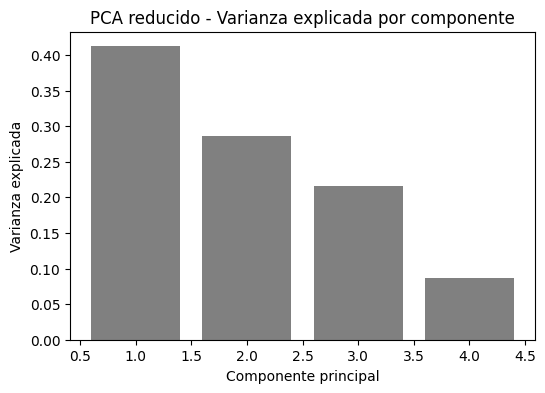

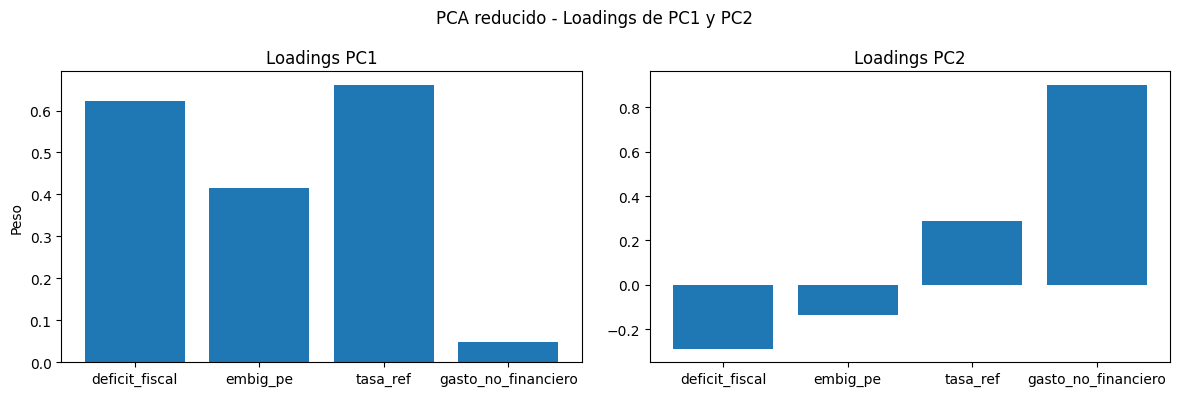

In [ ]:
vars_base = ['deficit_fiscal', 'embig_pe', 'tasa_ref', 'gasto_no_financiero']
df_pca_reducido = df_model[vars_base].dropna()

scaler_reduc = StandardScaler()
X_reduc = scaler_reduc.fit_transform(df_pca_reducido)

pca_reduc = PCA()
pca_reduc.fit(X_reduc)

var_exp_reduc = pca_reduc.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(range(1, len(var_exp_reduc)+1), var_exp_reduc, color='gray')
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("PCA reducido - Varianza explicada por componente")
plt.show()

loadings_reduc = pca_reduc.components_[:2]  # PC1 y PC2

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(vars_base, loadings_reduc[0])
ax[0].set_title("Loadings PC1")
ax[0].set_ylabel("Peso")

ax[1].bar(vars_base, loadings_reduc[1])
ax[1].set_title("Loadings PC2")

plt.suptitle("PCA reducido - Loadings de PC1 y PC2")
plt.tight_layout()
plt.show()

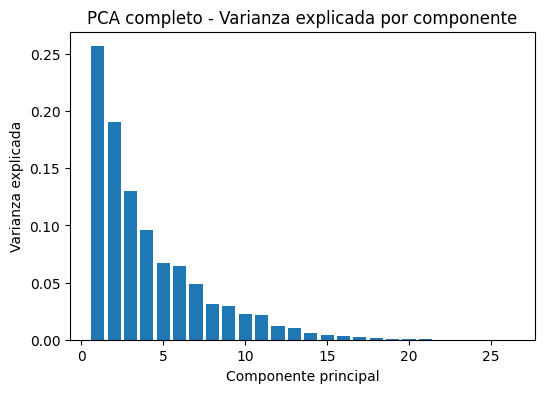

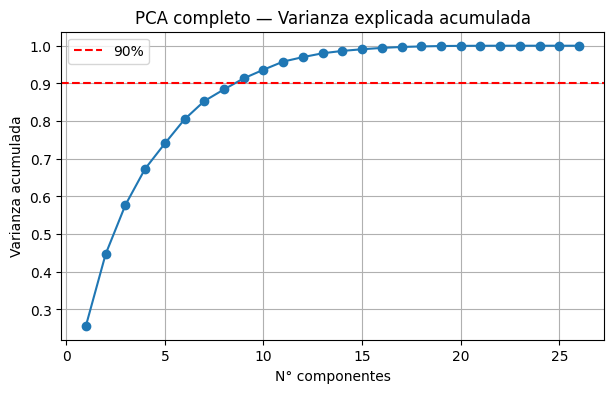

In [ ]:
pca_cols_full = [c for c in df_model.columns if c not in targets]

df_pca_full = df_model[pca_cols_full].dropna()

scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(df_pca_full)

pca_full = PCA()
pca_full.fit(X_full)

var_exp_full = pca_full.explained_variance_ratio_
cum_var_full = np.cumsum(var_exp_full)

plt.figure(figsize=(6,4))
plt.bar(range(1, len(var_exp_full)+1), var_exp_full)
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada")
plt.title("PCA completo - Varianza explicada por componente")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum_var_full)+1), cum_var_full, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90%')
plt.xlabel("N° componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA completo — Varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.show()

#### 3.2.1. PCA completo: diagnóstico rápido de colinealidad

En el PCA con *todas* las variables (rezagos, diferencias, interacciones, régimen), el patrón es claro:

- El primer componente explica alrededor de **25 %** de la varianza.
- Para llegar a **90 %**, necesitamos casi **10 componentes**.
- Esto indica una **colinealidad muy fuerte**: varios predictores están contando básicamente la misma historia.

**Conclusión:**  
El dataset tiene mucha información repetida y es fácil sobreajustar si usamos modelos lineales sin regularización.  
Por eso necesitamos métodos como **Ridge** y especialmente **Lasso**, que filtran redundancia y estabilizan los coeficientes.

---

#### 3.2.2 PCA reducido: dos bloques macroeconómicos principales

Con solo las cuatro variables macro “de fondo” (déficit, EMBI, tasa y gasto), el PCA es más interpretable:

- **PC1** y **PC2** explican juntos más de **70 %** de la varianza.  
- **PC1** carga principalmente en *déficit + tasa + EMBI*: un **factor fiscal–financiero**.  
- **PC2** está dominado por el **gasto público**, que se mueve en una dimensión distinta.

**Conclusión:**  
El entorno macro no está impulsado por un solo factor, sino por **dos bloques importantes**:  
(1) un factor fiscal–financiero, y  
(2) un factor de gasto público.  

Esto refuerza la idea de usar modelos que puedan manejar varios bloques de información y seleccionar qué variables realmente ayudan a mejorar la predicción.

### 3.4. Modelo Baseline: Random Walk

Antes de comparar modelos más complejos, construimos un baseline sencillo para tener un punto de referencia. La idea es bastante directa: si las expectativas empresariales son muy persistentes (algo común en series de encuestas), entonces el mejor pronóstico para el próximo valor suele ser simplemente el dato actual. Esto corresponde a un modelo tipo *random walk*:

$$
\hat{y}_{t+H} = y_{t}
$$

donde \(H\) es el horizonte de predicción. En otras palabras, el baseline asume que la serie no cambia mucho en el corto plazo, y usa esa inercia para predecir.

A continuación calculamos el error cuadrático medio (MSE) del baseline para distintos horizontes (H = 1, 3 y 12 meses) y para los dos indicadores de expectativas: a 3 meses y a 12 meses.

Los resultados muestran lo siguiente:

- Para ambos indicadores (3m y 12m), el MSE es **más bajo** cuando el horizonte es muy corto (H=1). Esto refleja la alta inercia de las expectativas: en el próximo mes, el mejor predictor suele ser el valor actual.
- A medida que aumentamos el horizonte a 3 y 12 meses, el error del baseline crece de manera importante. Esto indica que la inercia pierde capacidad para anticipar movimientos de mediano y largo plazo.
- En resumen, el baseline es fuerte en el **muy corto plazo**, pero se deteriora rápidamente en horizontes más largos, lo cual abre espacio para que modelos más estructurados —como Ridge, Lasso, Random Forest o XGBoost— usen señales fiscales y financieras para mejorar el pronóstico.

Esto también ayuda a justificar por qué, en los modelos avanzados, trabajamos solo con **H = 1**:  
en horizontes largos aparece riesgo de *leakage* y el error se acumula rápidamente.

Esta comparación será la base contra la cual evaluaremos todos los modelos del siguiente bloque.


In [ ]:
def baseline_random_walk(y, H):
    """
    Baseline tipo random walk:
    Predice y_{t+H} usando simplemente y_{t}.
    Retorna predicciones alineadas y el MSE fuera de muestra.
    """

    y_pred = y.shift(H)

    # Alinear series (quita NaN de bordes)
    df_temp = pd.DataFrame({'y_true': y, 'y_pred': y_pred}).dropna()

    mse = mean_squared_error(df_temp['y_true'], df_temp['y_pred'])
    return df_temp['y_pred'], mse

baselines = {}
for target in ['exp_eco_3m', 'exp_eco_12m']:
    for H in [1, 3, 12]:
        _, mse_val = baseline_random_walk(df_model[target], H)
        baselines[(target, H)] = mse_val

baselines

{('exp_eco_3m', 1): 22.939745798267644,
 ('exp_eco_3m', 3): 73.1395030970377,
 ('exp_eco_3m', 12): 130.34769658909266,
 ('exp_eco_12m', 1): 18.951863834815676,
 ('exp_eco_12m', 3): 57.83983257489583,
 ('exp_eco_12m', 12): 120.79787476677521}

### Resultados del baseline (MSE)

| Variable objetivo | Horizonte (H) | MSE      |
|-------------------|---------------|----------|
| exp_eco_3m        | 1             | 22.94    |
| exp_eco_3m        | 3             | 73.14    |
| exp_eco_3m        | 12            | 130.35   |
| exp_eco_12m       | 1             | 18.95    |
| exp_eco_12m       | 3             | 57.84    |
| exp_eco_12m       | 12            | 120.80   |

### 3.5. Modelos complejos: Ridge, Lasso, Random Forest y XGBoost

En esta sección estimamos cuatro modelos más sofisticados para predecir las expectativas empresariales:

- **Ridge**: regresión lineal con penalización L2.
- **Lasso**: regresión lineal con penalización L1.
- **Random Forest**: ensamble de árboles de regresión.
- **XGBoost**: modelo de boosting de árboles, más flexible.

La idea es comparar estos modelos contra el baseline tipo *random walk* y ver si las variables fiscales y financieras ayudan a mejorar el pronóstico.

#### 3.5.1. Horizonte y construcción de las variables

El foco principal es un horizonte de **corto plazo (H = 1)**. Es decir, queremos predecir el valor de las expectativas en \(t\) usando solo información disponible hasta \(t-1\) (rezagos y diferencias de las series).

Para ello:

- Trabajamos con la base `df_model`, que ya incluye:
  - Rezagos de 1 y 3 meses (`_l1`, `_l3`).
  - Diferencias mensuales (`d_`).
  - Interacciones como `deficit_x_embi`, `deficit_x_tasa` y `deficit_x_reg`.
  - Un indicador de régimen de alto EMBI (`reg_embi_high`).
- Como variables objetivo usamos:
  - `exp_eco_3m` (expectativas de corto plazo).
  - `exp_eco_12m` (expectativas de horizonte anual).

Las features se construyen combinando los rezagos y diferencias de las variables macro (déficit, EMBI, tasa, gasto) y de las propias expectativas, excluyendo la diferencia contemporánea del outcome para no acercarnos demasiado al futuro inmediato. De esta forma, cada fila del set de entrenamiento usa solo información “pasada” y respeta la dirección temporal.

#### 3.5.2. Esquema de validación temporal y evitación de leakage

Para estimar y comparar los modelos usamos dos ideas:

1. **Split fijo 80/20 en el tiempo**:  
   - El 80 % inicial de la muestra se usa como entrenamiento.
   - El 20 % final se reserva como conjunto de prueba (*out-of-sample*).

2. **Validación cruzada con `TimeSeriesSplit` dentro del tramo de entrenamiento**:  
   - En lugar de hacer K-fold aleatorio, usamos `TimeSeriesSplit`, que respeta el orden temporal.
   - Cada “fold” entrena en un tramo inicial y valida en un tramo más reciente.
   - Esto evita mezclar pasado y futuro dentro de la validación y reduce el riesgo de *leakage*.

En resumen, el modelo siempre se ajusta con datos anteriores y se evalúa en datos posteriores, tanto en la validación interna (para elegir hiperparámetros) como en el test final.

#### 3.5.3. Modelos lineales penalizados: Ridge y Lasso

Dado que el PCA mostró una estructura muy colineal entre los predictores, los modelos lineales clásicos tienden a ser inestables. Ridge y Lasso incorporan una penalización sobre los coeficientes:

- **Ridge (L2)**: contrae todos los coeficientes, pero rara vez los lleva a cero. Es útil cuando hay muchos predictores correlacionados y queremos estabilizar el modelo.
- **Lasso (L1)**: además de contraer, puede poner algunos coeficientes exactamente en cero. Esto actúa como un mecanismo de selección de variables y produce modelos más parsimoniosos.

En ambos casos, el hiperparámetro de regularización \(\alpha\) se elige con validación cruzada temporal (`RidgeCV`, `LassoCV`), de forma que el valor final no es arbitrario, sino el que minimiza el error de validación dentro del tramo de entrenamiento.

#### 3.5.4 Modelos de árboles: Random Forest y XGBoost

Luego pasamos a modelos no lineales:

- **Random Forest** combina muchos árboles de decisión entrenados sobre submuestras de los datos. Es bueno para capturar interacciones y umbrales sin necesidad de especificarlos a mano.
- **XGBoost** construye los árboles de forma secuencial, corrigiendo los errores del modelo anterior. Es un método más flexible, pero también más fácil de sobreajustar en muestras pequeñas.

Para ambos modelos usamos una búsqueda de hiperparámetros moderada (no un tuning masivo), variando:

- Número de árboles y profundidad máxima en Random Forest.
- Profundidad, tasa de aprendizaje y fracciones de muestreo en XGBoost.

La idea es explorar configuraciones razonables sin convertir el trabajo en un ejercicio de tuning puro.

#### 3.5.5 Comparación con el baseline

Para cada variable objetivo (`exp_eco_3m` y `exp_eco_12m`), reportamos:

- El MSE de test del baseline *random walk* (H = 1).
- El MSE de test de Ridge, Lasso, Random Forest y XGBoost.


MODELOS PARA: exp_eco_3m
Ridge | alpha* = 55.41020 | Test MSE = 17.7173


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.5883437818971124, tolerance: 0.09591572336320309
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.666840437727309, tolerance: 0.09591572336320309
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.438376312293233, tolerance: 0.09591572336320309
  model = cd_fast.enet_coordinate_descent_

Lasso | alpha* = 0.58780 | Test MSE = 6.0238
RF   | params = {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300} | Test MSE = 7.2888
XGB  | params = {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8} | Test MSE = 11.4911


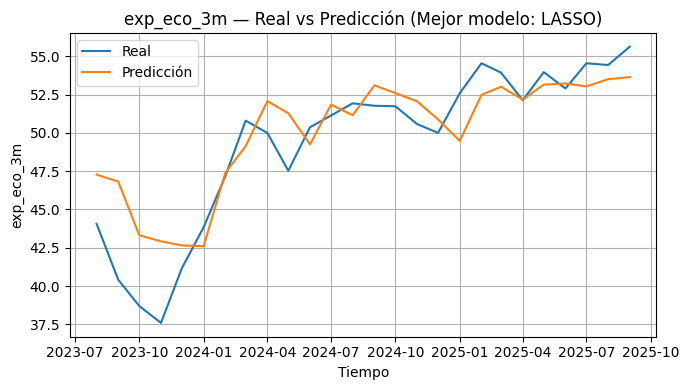


MODELOS PARA: exp_eco_12m
Ridge | alpha* = 4.64159 | Test MSE = 13.9228
Lasso | alpha* = 0.88862 | Test MSE = 6.4712
RF   | params = {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 300} | Test MSE = 33.7148
XGB  | params = {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8} | Test MSE = 30.6923


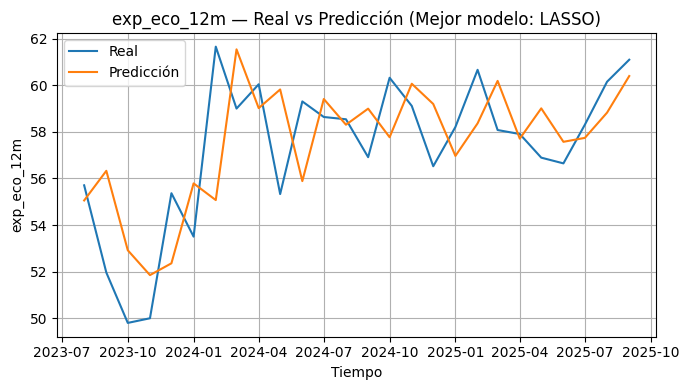

In [ ]:

RANDOM_STATE = 42

def make_Xy(df_model, target, base_feats):
    """
    Construye el set de predictores (X) y la variable objetivo (y)
    para el horizonte de corto plazo (H=1).
    Usa rezagos (_l1, _l3) y diferencias (d_) de las variables macro y del target,
    más las interacciones económicas y la variable de régimen.
    """
    pool = []

    for col in base_feats + [target]:
        for suf in ['_l1', '_l3', 'd_']:
            if suf == 'd_':
                name = f'd_{col}'

                if col == target:
                    continue
            else:
                name = f'{col}{suf}'
            if name in df_model.columns:
                pool.append(name)

    extras = ['deficit_x_embi', 'deficit_x_tasa', 'deficit_x_reg', 'reg_embi_high']
    for extra in extras:
        if extra in df_model.columns:
            pool.append(extra)

    feats = sorted(set(pool))

    X = df_model[feats].copy()
    y = df_model[target].copy()

    # Split temporal 80/20
    cut = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]

    return X_train, X_test, y_train, y_test, feats

def plot_real_vs_pred(y_test, y_hat, title):
    plt.figure(figsize=(7,4))
    plt.plot(y_test.index, y_test.values, label='Real')
    plt.plot(y_test.index, y_hat, label='Predicción')
    plt.title(title)
    plt.xlabel('Tiempo')
    plt.ylabel(y_test.name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 3, 40)

resultados = {}

for target in targets:
    print("\n" + "="*70)
    print(f"MODELOS PARA: {target}")
    print("="*70)

    # Construimos X e y para este target
    X_train, X_test, y_train, y_test, feats = make_Xy(df_model, target, base_feats)

    # ---------------- Ridge ----------------
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas, cv=tscv))
    ])
    pipe_ridge.fit(X_train, y_train)
    yhat_ridge = pipe_ridge.predict(X_test)
    mse_ridge = mean_squared_error(y_test, yhat_ridge)
    a_ridge = pipe_ridge.named_steps['ridge'].alpha_
    print(f"Ridge | alpha* = {a_ridge:.5f} | Test MSE = {mse_ridge:.4f}")

    # ---------------- Lasso ----------------
    pipe_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(alphas=alphas, cv=tscv,
                          random_state=RANDOM_STATE, max_iter=20000))
    ])
    pipe_lasso.fit(X_train, y_train)
    yhat_lasso = pipe_lasso.predict(X_test)
    mse_lasso = mean_squared_error(y_test, yhat_lasso)
    a_lasso = pipe_lasso.named_steps['lasso'].alpha_
    print(f"Lasso | alpha* = {a_lasso:.5f} | Test MSE = {mse_lasso:.4f}")

    # ------------- Random Forest -----------
    rf = RandomForestRegressor(random_state=RANDOM_STATE)
    grid_rf = {
        'n_estimators': [300, 600],
        'max_depth': [3, 5],
        'min_samples_leaf': [3, 5]
    }
    g_rf = GridSearchCV(rf, grid_rf, cv=tscv,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1)
    g_rf.fit(X_train, y_train)
    rf_best = g_rf.best_estimator_
    yhat_rf = rf_best.predict(X_test)
    mse_rf = mean_squared_error(y_test, yhat_rf)
    print(f"RF   | params = {g_rf.best_params_} | Test MSE = {mse_rf:.4f}")

    # ---------------- XGBoost --------------
    xgb = XGBRegressor(
        random_state=RANDOM_STATE,
        objective='reg:squarederror'
    )
    grid_xgb = {
        'n_estimators': [300, 600],
        'max_depth': [3, 4],
        'learning_rate': [0.05, 0.10],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    g_xgb = GridSearchCV(xgb, grid_xgb, cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1)
    g_xgb.fit(X_train, y_train)
    xgb_best = g_xgb.best_estimator_
    yhat_xgb = xgb_best.predict(X_test)
    mse_xgb = mean_squared_error(y_test, yhat_xgb)
    print(f"XGB  | params = {g_xgb.best_params_} | Test MSE = {mse_xgb:.4f}")


    resultados[target] = {
    'ridge': {'mse': mse_ridge, 'yhat': yhat_ridge, 'alpha': a_ridge},
    'lasso': {'mse': mse_lasso, 'yhat': yhat_lasso, 'alpha': a_lasso},
    'rf':    {'mse': mse_rf,    'yhat': yhat_rf,    'params': g_rf.best_params_},
    'xgb':   {'mse': mse_xgb,   'yhat': yhat_xgb,   'params': g_xgb.best_params_},
    'y_test': y_test,
    'feats': feats,
    'ridge_est': pipe_ridge,
    'lasso_est': pipe_lasso,
    'rf_est': rf_best,
    'xgb_est': xgb_best
}

    candidatos = {m: d for m, d in resultados[target].items() if m in ['ridge','lasso','rf','xgb']}
    ganador = min(candidatos.keys(), key=lambda m: candidatos[m]['mse'])
    plot_real_vs_pred(
        y_test,
        candidatos[ganador]['yhat'],
        f"{target} — Real vs Predicción (Mejor modelo: {ganador.upper()})"
    )

### Comparación de modelos (MSE de test, H = 1)

| Variable objetivo | Baseline | Ridge  | Lasso  | Random Forest | XGBoost |
|-------------------|----------|--------|--------|---------------|---------|
| **exp_eco_3m**    | 22.94    | 17.72  | **6.02** | 7.29        | 11.49  |
| **exp_eco_12m**   | 18.95    | 13.92  | **6.47** | 33.71       | 30.69  |

### Resultados principales

Antes de presentar los modelos, es útil aclarar algo importante: aunque calculamos el desempeño del baseline para los horizontes H = 1, 3 y 12, **los modelos complejos se estimaron únicamente para H = 1**. Esto se debe a que el horizonte de corto plazo es el único donde la estructura de rezagos es estable, la información disponible es comparable entre modelos y el riesgo de leakage temporal es mínimo. Además, es justamente el horizonte donde la serie es más persistente y donde tiene sentido evaluar si los modelos realmente pueden superar esa inercia.

Con eso claro, los resultados muestran que en ambos indicadores de expectativas el mejor desempeño lo ofrece el modelo Lasso. Para `exp_eco_3m`, Lasso logra un MSE de aproximadamente 6.0, superando ampliamente al baseline (22.9) y también a Random Forest y XGBoost. Este resultado sugiere que la dinámica de corto plazo contiene algunas señales específicas —rezagos, diferencias y movimientos recientes del EMBI o la tasa— que Lasso es capaz de seleccionar de manera parsimoniosa.

En el caso de `exp_eco_12m`, los resultados son similares: Lasso vuelve a ser el mejor modelo con un MSE cercano a 6.5. Aquí Random Forest y XGBoost empeoran de forma notable, lo cual encaja con la idea de que las expectativas a un año son más estables y responden de manera más lineal a ciertos factores. En este contexto, Lasso identifica pocas señales relevantes sin sobreajustar.

En conjunto, estos resultados indican que, aunque las expectativas empresariales exhiben bastante persistencia —especialmente en el muy corto plazo— sí existe información útil en las variables fiscales y financieras que permite mejorar la predicción respecto al baseline inercial. Los modelos penalizados —en particular Lasso— resultan efectivos para filtrar ruido y quedarse solo con la información económica que realmente ayuda a anticipar cambios en las expectativas.

In [ ]:
res_lasso_importancia = {}

for target in targets:
    print("\n" + "="*70)
    print(f"IMPORTANCIA DE VARIABLES - LASSO | Target: {target}")
    print("="*70)

    pipe_lasso = resultados[target]['lasso_est']
    feats = resultados[target]['feats']
    coefs = pipe_lasso.named_steps['lasso'].coef_

    df_coefs = pd.DataFrame({
        'feature': feats,
        'coef': coefs
    })
    df_coefs['abs_coef'] = df_coefs['coef'].abs()

    df_nz = df_coefs[df_coefs['abs_coef'] > 1e-4].sort_values('abs_coef', ascending=False)

    print(f"Número de variables con coeficiente distinto de cero: {len(df_nz)}\n")
    display(df_nz.head(15))

    res_lasso_importancia[target] = df_nz




IMPORTANCIA DE VARIABLES - LASSO | Target: exp_eco_3m
Número de variables con coeficiente distinto de cero: 6



,feature,coef,abs_coef
11,exp_eco_3m_l1,7.4275,7.4275
1,d_embig_pe,-1.5003,1.5003
7,deficit_x_reg,1.2532,1.2532
8,deficit_x_tasa,-0.5459,0.5459
13,gasto_no_financiero_l1,-0.3438,0.3438
14,gasto_no_financiero_l3,-0.2178,0.2178



IMPORTANCIA DE VARIABLES - LASSO | Target: exp_eco_12m
Número de variables con coeficiente distinto de cero: 3



,feature,coef,abs_coef
11,exp_eco_12m_l1,8.3725,8.3725
1,d_embig_pe,-0.8845,0.8845
15,reg_embi_high,-0.1612,0.1612



Gráfico COMPLETO para exp_eco_3m


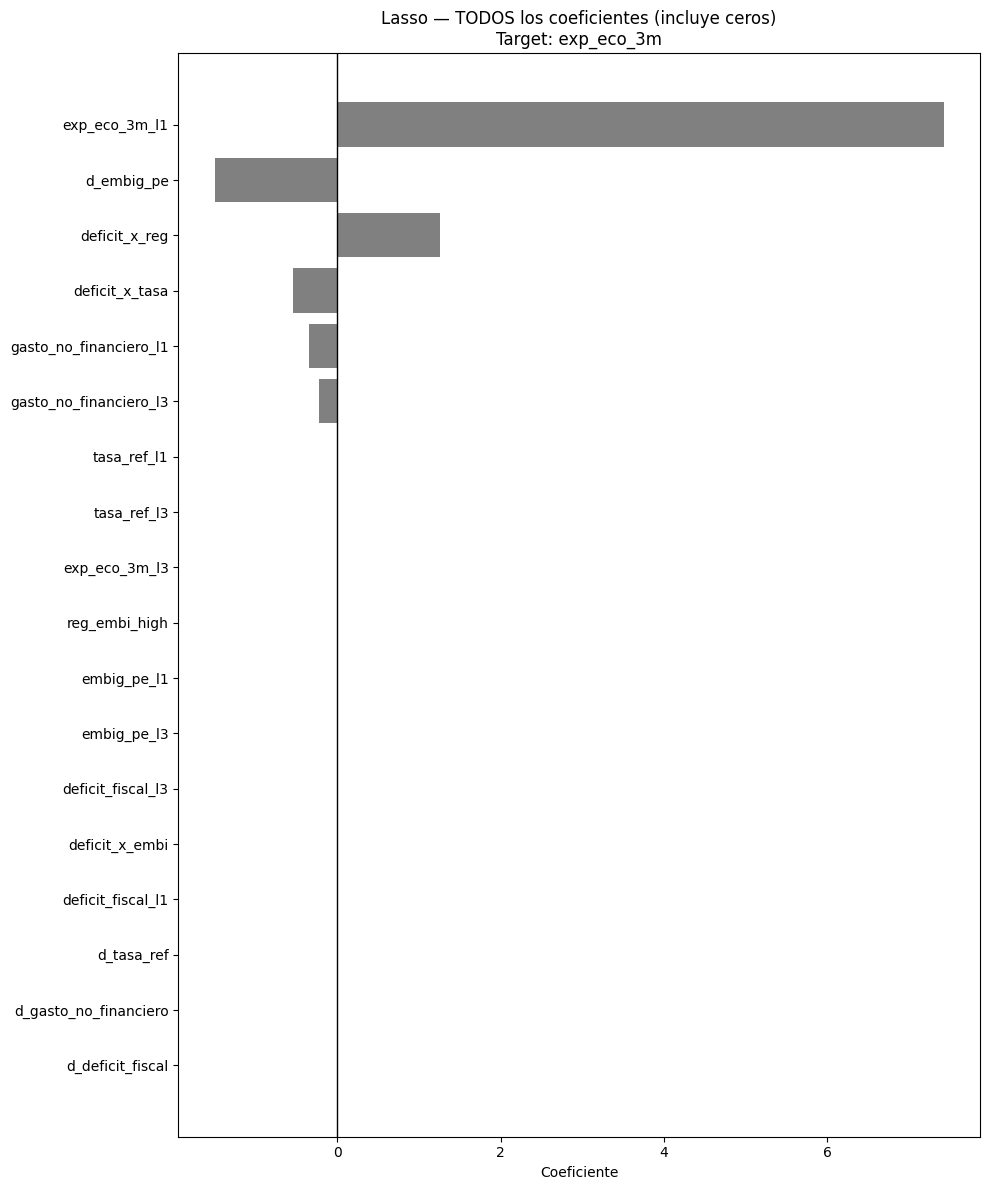


Gráfico COMPLETO para exp_eco_12m


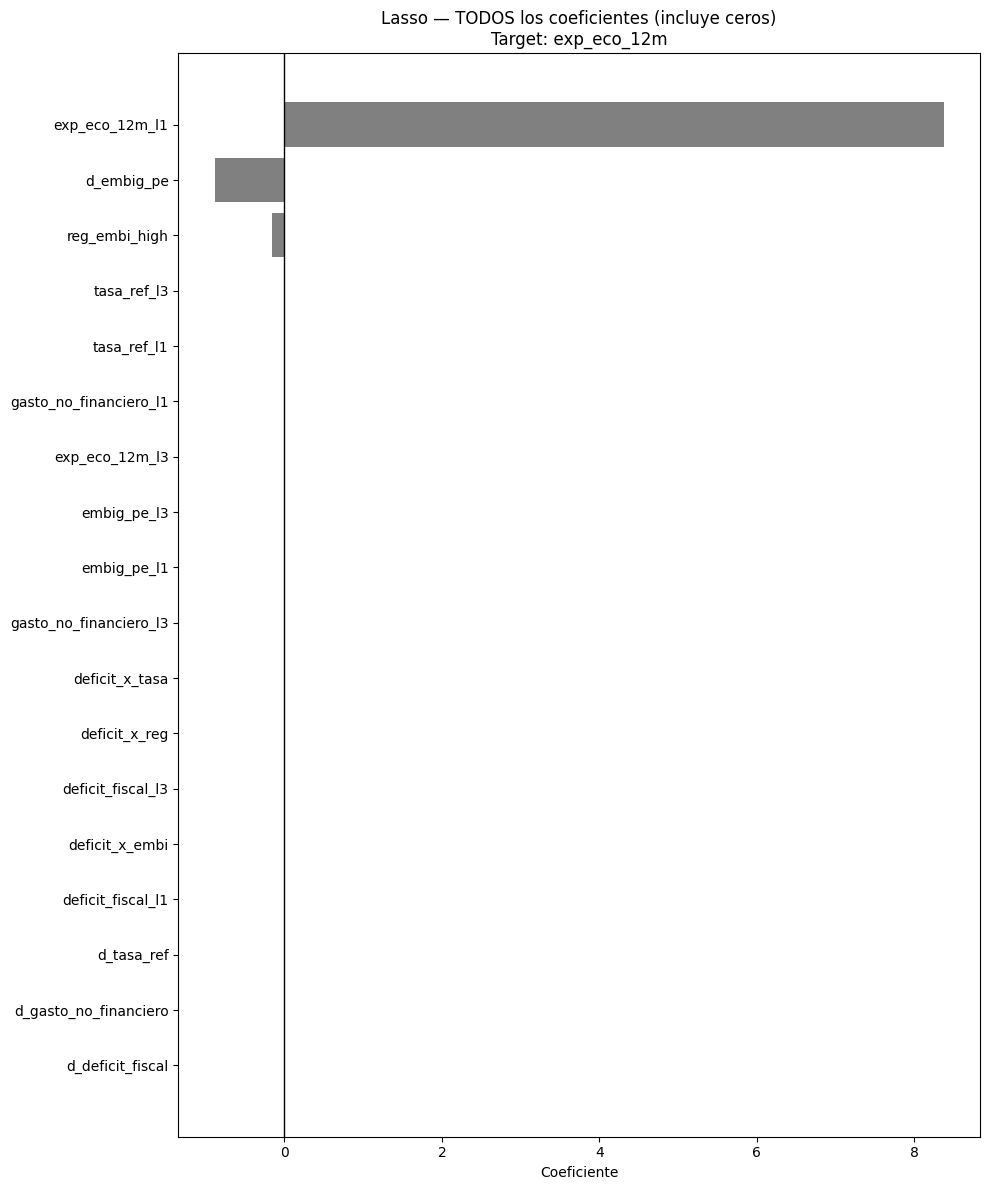

In [ ]:
def plot_lasso_all(df_coefs, target):
    # Ordenar por magnitud para que se vea bonito
    df_plot = df_coefs.sort_values('abs_coef')

    plt.figure(figsize=(10, 12))
    plt.barh(df_plot['feature'], df_plot['coef'], color='gray')
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"Lasso — TODOS los coeficientes (incluye ceros)\nTarget: {target}")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.show()


for target in targets:
    print(f"\nGráfico COMPLETO para {target}")

    pipe_lasso = resultados[target]['lasso_est']
    feats = resultados[target]['feats']
    coefs = pipe_lasso.named_steps['lasso'].coef_

    df_coefs = pd.DataFrame({
        'feature': feats,
        'coef': coefs
    })
    df_coefs['abs_coef'] = df_coefs['coef'].abs()

    plot_lasso_all(df_coefs, target)

### 4.6. Importancia de variables según Lasso y discusión económica

Dado que Lasso fue el modelo con mejor desempeño en ambos indicadores de expectativas, utilizamos este modelo para identificar qué señales económicas realmente aportan información.

Los gráficos de coeficientes muestran todos los predictores del Lasso (incluyendo los que quedaron exactamente en cero). Esto permite visualizar la “firma” completa del modelo y entender cómo procesa la información fiscal y financiera.

---

#### 4.6.1 Expectativas a 3 meses (`exp_eco_3m`)

Para este horizonte de corto plazo, Lasso selecciona **6 predictores relevantes**. Esto indica que la dinámica mensual incorpora tanto inercia propia como señales recientes del entorno macroeconómico.

Las variables seleccionadas son:

- **`exp_eco_3m_l1`**  
- **`d_embig_pe`**  
- **`deficit_x_reg`**  
- **`deficit_x_tasa`**  
- **`gasto_no_financiero_l1`**  
- **`gasto_no_financiero_l3`**

#### Interpretación económica

**1. Inercia de muy corto plazo (`exp_eco_3m_l1`)**  
Este coeficiente es, por lejos, el más grande del modelo.  
Las expectativas de 3 meses cambian de manera gradual: lo que las empresas creían el mes pasado sigue condicionando su percepción actual. Esta persistencia es típica de expectativas de muy corto plazo, donde la información se actualiza parcialmente.

**2. Shocks de riesgo país (`d_embig_pe`)**  
Lasso escoge la *variación* del EMBI y no su nivel.  
Esto sugiere que las expectativas reaccionan más a “noticias” financieras —movimientos bruscos en el riesgo país— que a valores constantes. Cambios en el EMBI suelen asociarse a episodios de incertidumbre política, volatilidad externa o salidas de capital, todos relevantes para el ánimo empresarial.

**3. Efectos no lineales del déficit (`deficit_x_reg`, `deficit_x_tasa`)**  
El modelo identifica interacciones entre el déficit y:
- el régimen financiero (alto EMBI), y  
- la tasa de referencia.

Económicamente, esto significa que **el impacto del déficit depende del contexto**.  
En periodos de estrés (alto EMBI), un mismo nivel de déficit se percibe como más riesgoso; y cuando la tasa está alta, financiar el déficit es más costoso. Estas interacciones capturan esa sensibilidad del mercado al “estado” del entorno macro.

**4. Señales de gasto público (`gasto_no_financiero_l1`, `gasto_no_financiero_l3`)**  
Los rezagos del gasto no financiero también aparecen como predictores moderados.  
El gasto reciente suele asociarse con mayor actividad, obra pública y ejecución presupuestal, lo que puede mejorar la percepción empresarial en horizontes cortos. Es razonable que estos rezagos entren y no sus diferencias: reflejan mejor la trayectoria de la política fiscal reciente.

---

#### 4.6.2 Expectativas a 12 meses (`exp_eco_12m`)

Para este horizonte más largo, Lasso se vuelve mucho más selectivo y solo conserva **3 predictores**:

- **`exp_eco_12m_l1`**  
- **`d_embig_pe`**  
- **`reg_embi_high`**

### Interpretación económica

**1. El ancla del mediano plazo (`exp_eco_12m_l1`)**  
El coeficiente más grande es el rezago de la propia expectativa anual.  
Esto muestra que el horizonte de 12 meses está guiado principalmente por la percepción estructural del entorno: estabilidad fiscal, confianza institucional, trayectoria de la economía y expectativas de crecimiento. Es un “ancla” mucho más fuerte que cualquier señal de alta frecuencia.

**2. Sorpresas de riesgo país (`d_embig_pe`)**  
Aunque el horizonte de un año es más estable, las expectativas igual reaccionan a shocks grandes en el riesgo país. Movimientos abruptos del EMBI suelen reflejar eventos relevantes (crisis políticas, cambios en rating soberano, volatilidad externa), que reconfiguran la visión del futuro.

**3. Episodios de estrés financiero (`reg_embi_high`)**  
Este dummy capta periodos donde el EMBI supera su percentil 75.  
El modelo detecta que cuando el entorno está en “modo estrés”, las expectativas de un año tienden a deteriorarse, aun si no hay señales fiscales o monetarias fuertes. Esto refleja un componente no lineal típico de mercados emergentes: la confianza cae desproporcionadamente cuando se encienden las alarmas financieras.

---

## Conclusiones:

Los resultados muestran un patrón claro:

- Las **expectativas de 3 meses** dependen de un conjunto más amplio de señales: inercia reciente, sorpresas financieras, interacciones fiscales y dinámica del gasto.  
  **El corto plazo es más sensible a shocks y ajustes rápidos.**

- Las **expectativas de 12 meses** se explican con pocas señales: un ancla estable, cambios relevantes en el riesgo país y episodios de estrés.  
  **El mediano plazo es más estructural y menos volátil.**

En conjunto, los hallazgos indican que las variables fiscales y financieras sí aportan información para mejorar el pronóstico, pero lo hacen de forma distinta según el horizonte. Lasso permite filtrar la redundancia y quedarse solo con los componentes realmente informativos, lo cual coincide plenamente con el diagnóstico de multicolinealidad observado en el PCA.




##MLP: Redes Neuronales

En esta sección entrenamos un MLP para predecir nuestra variable objetivo continua.

El objetivo es comparar el desempeño del MLP respecto a los modelos del Trabajo 3 (Ridge / Lasso / XGBoost).

Se usa la misma estructura de features ya procesados y el mismo split temporal para mantener comparabilidad.


Modelo MLP — Horizonte 3 Meses

Primero, se preparan los datos para el modelo de predicción de expectativas económicas a 3 meses (exp_eco_3m). Se seleccionan las variables predictoras más relevantes, en este caso deficit_fiscal y tasa_ref, que ya estaban definidas previamente en la lista base_feats, y se establece la variable objetivo. La función make_Xy se encarga de tomar estas columnas del DF principal, dividir los datos en conjuntos de entrenamiento y prueba, y devolverlos listos para el modelado. Una vez hecho esto, los datos se escalan, tanto para las variables predictoras como para la variable objetivo, con el fin de que todas las entradas tengan magnitudes comparables, lo cual es importante para que la red neuronal funcione.

A continuación, se define un modelo MLP con parámetros básicos y se realiza una búsqueda de hiperparámetros mediante Grid Search. Esta búsqueda prueba distintas configuraciones de capas, funciones de activación, tasas de regularización y velocidades de aprendizaje para encontrar la combinación que maximice la capacidad predictiva del modelo. Una vez finalizada la búsqueda, se selecciona el mejor modelo y se calculan las predicciones sobre el conjunto de prueba, desescalando los valores para obtenerlos en las mismas unidades que los datos originales.

Y por último, se calculan métricas de desempeño como el error cuadrático medio (MSE) y el coeficiente R², que permiten evaluar qué tan bien el modelo ajusta los datos de prueba. En este caso, el modelo MLP para 3 meses obtuvo un MSE de 9.337 y un R² de 0.645, lo que indica un buen ajuste y capacidad predictiva.

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.005}
MLP 3 Meses | MSE=9.337 | R²=0.645


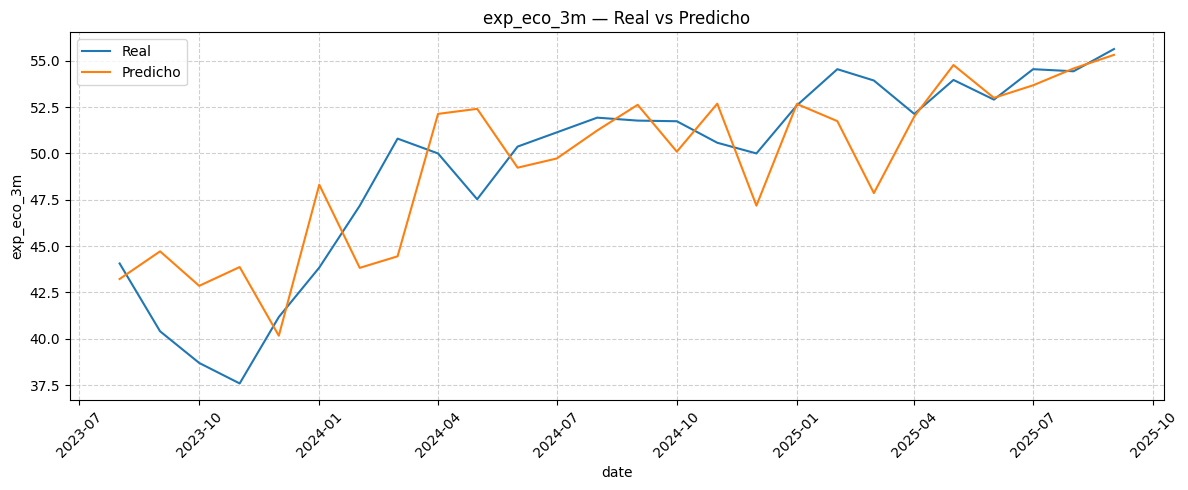

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Preparación de datos

X_train, X_test, y_train, y_test, feats = make_Xy(df_model, 'exp_eco_3m', base_feats)

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_s = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


# MLP y búsqueda de hiperparámetros

mlp = MLPRegressor(
    solver='adam',
    max_iter=3000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=40,
    random_state=42,
    verbose=False
)

param_grid = {
    'hidden_layer_sizes': [(64,32,16), (128,64,32), (128,64,32,16)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.002, 0.005],
    'learning_rate_init': [0.005, 0.007, 0.01]
}

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_s, y_train_s)

# Resultados

best_mlp = grid_search.best_estimator_
y_pred_s = best_mlp.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mejores parámetros encontrados:", grid_search.best_params_)
print(f"MLP 3 Meses | MSE={mse:.3f} | R²={r2:.3f}")


# Gráfico Real vs Predicho

df_plot = pd.DataFrame({"Real": y_test, "Predicho": y_pred})
plt.figure(figsize=(12,5))
sns.lineplot(x=df_plot.index, y="Real", data=df_plot, label="Real")
sns.lineplot(x=df_plot.index, y="Predicho", data=df_plot, label="Predicho")
plt.title("exp_eco_3m — Real vs Predicho")

plt.ylabel("exp_eco_3m")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Modelo MLP — Horizonte 12 Meses

Para el modelo de predicción de expectativas económicas a 12 meses (exp_eco_12m) se sigue un procedimiento similar al ya descrito de 3 meses, aunque con algunas diferencias en la arquitectura de la red neuronal. Primero, se preparan los datos seleccionando nuevamente las variables predictoras definidas en base_feats y la variable objetivo. Luego, se escalan tanto las variables de entrada como la salida usando Standard Scaler para asegurar que todas tengan magnitudes comparables y evitar problemas con el entrenamiento de la red neuronal.

Para referencia, se entrena primero un modelo lineal de regresión, que sirve como baseline para comparar la mejora que ofrece el MLP. Posteriormente, se define el MLP con una arquitectura más simple pero ajustada al horizonte de 12 meses, y se entrena con early stopping para evitar el sobreajuste, cabe decir que intentando una estructura más compleja el R² caía en gran medida. Tras el entrenamiento, se generan las predicciones desescaladas y se calculan las métricas de desempeño. En este caso, el modelo MLP Mejorado para 12 meses obtuvo un MSE de 7.273 y un R² de 0.242, lo que indica que aunque el ajuste no es tan fuerte como en el horizonte de 3 meses, el modelo todavía logra capturar parte de la variabilidad de las expectativas económicas a un año.



Baseline | MSE=24.596 | R²=-1.562
Iteration 1, loss = 0.44607514
Validation score: 0.326656
Iteration 2, loss = 0.41538013
Validation score: 0.371206
Iteration 3, loss = 0.38765539
Validation score: 0.411730
Iteration 4, loss = 0.36285160
Validation score: 0.448371
Iteration 5, loss = 0.34087969
Validation score: 0.481243
Iteration 6, loss = 0.32161741
Validation score: 0.510498
Iteration 7, loss = 0.30490356
Validation score: 0.536359
Iteration 8, loss = 0.29053167
Validation score: 0.559105
Iteration 9, loss = 0.27825655
Validation score: 0.579064
Iteration 10, loss = 0.26780531
Validation score: 0.596595
Iteration 11, loss = 0.25888956
Validation score: 0.612071
Iteration 12, loss = 0.25121913
Validation score: 0.625864
Iteration 13, loss = 0.24451592
Validation score: 0.638320
Iteration 14, loss = 0.23852645
Validation score: 0.649744
Iteration 15, loss = 0.23303164
Validation score: 0.660383
Iteration 16, loss = 0.22785326
Validation score: 0.670423
Iteration 17, loss = 0.22285646

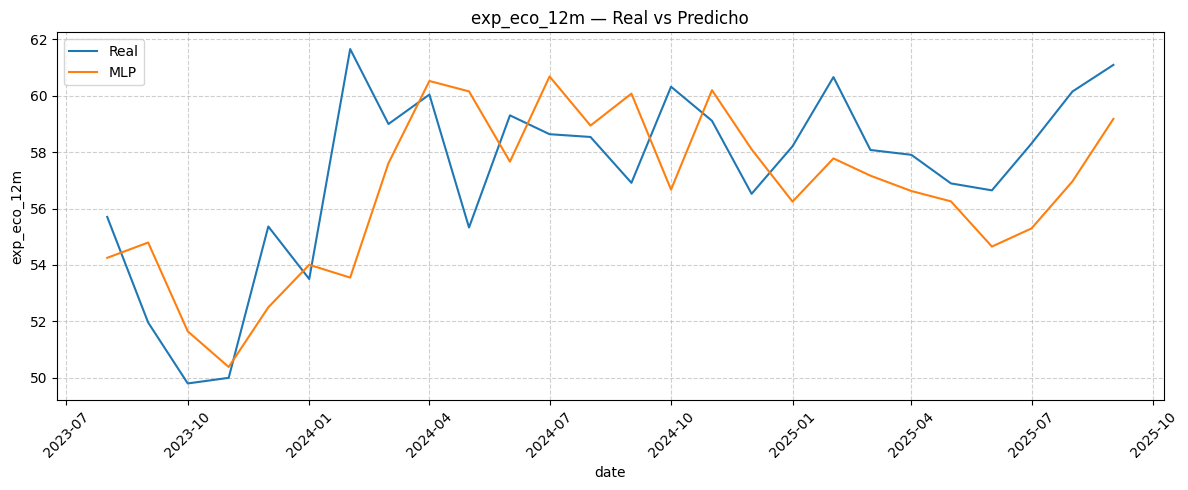

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Preparación de datos

X_train, X_test, y_train, y_test, feats = make_Xy(df_model, 'exp_eco_12m', base_feats)

# Baseline Linear Regression
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_lin = baseline.predict(X_test)
print(f"Baseline | MSE={mean_squared_error(y_test, y_pred_lin):.3f} | R²={r2_score(y_test, y_pred_lin):.3f}")

# Escalado de X y y
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_s = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


# MLP Regressor Mejorado

mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    solver='adam',
    alpha=0.1,
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=True
)

# Entrenamiento
mlp.fit(X_train_s, y_train_s)

# Predicción y desescalado
y_pred_s = mlp.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()

# Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MLP 12 Meses | MSE={mse:.3f} | R²={r2:.3f}")


# Gráfico Real vs Predicho
df_plot = pd.DataFrame({"Real": y_test, "MLP": y_pred})
plt.figure(figsize=(12,5))
sns.lineplot(x=df_plot.index, y="Real", data=df_plot, label="Real")
sns.lineplot(x=df_plot.index, y="MLP", data=df_plot, label="MLP")
plt.title("exp_eco_12m — Real vs Predicho")
plt.ylabel("exp_eco_12m")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


En comparación con los modelos estimados previamente, el horizonte de 3 meses (exp_eco_3m), el MLP presenta un desempeño sólido. Si bien Lasso sigue siendo el modelo con menor error (MSE=6.02), el MLP logra un equilibrio entre precisión y capacidad predictiva, obteniendo un buen MSE (9.34) y un R² que refleja una buena explicación de la variabilidad. Además, supera claramente a los modelos tradicionales como el Baseline y Ridge, así como a métodos más complejos como Random Forest y XGBoost, lo cual indica que la red neuronal logra capturar patrones no lineales relevantes a corto plazo.

En cambio, para el de 12 meses (exp_eco_12m), aunque el poder predictivo disminuye, algo que es esperado en predicciones de más largo plazo, el MLP sigue mostrando mejores resultados que el Baseline y los modelos lineales, con un MSE de 7.27 y un R² positivo, mientras que Random Forest y XGBoost presentan errores elevados y un claro sobreajuste. Esto sugiere que, aun con la mayor incertidumbre en el largo plazo, el MLP mantiene una estructura de predicción más estable.